# **Data Practicum II**

**Investigating the Co-occurrence of Supply Chain Gaps that are Driven by Business Closures in the US**

### Week 5: Sector-Sector Co-Occurence Modeling - TCN


##**Data Loading**

In [1]:
import pandas as pd
from pathlib import Path

df = pd.read_csv("df_merged.csv")

orig_shape = df.shape

# Filtering for years greater than 1999
numeric = pd.to_numeric(df['year'], errors='coerce')
year_int = numeric.where((numeric >= 1900) & (numeric <= 2100)).astype('Int64')
df['year'] = year_int
df = df[df['year'].notna() & (df['year'] > 1999)].copy()

# Converting the 'year' column to datetime for downstream operations
df['year'] = pd.to_datetime(df['year'].astype(int).astype(str) + '-01-01')

print(f"Original shape: {orig_shape}, after filtering year > 1999: {df.shape}")
print("Columns:", df.columns.tolist())
df.head()

Original shape: (470989, 33), after filtering year > 1999: (245779, 33)
Columns: ['Unnamed: 0', 'year', 'st', 'sector', 'fage', 'firms', 'estabs', 'emp', 'denom', 'estabs_entry', 'estabs_entry_rate', 'estabs_exit', 'estabs_exit_rate', 'job_creation', 'job_creation_births', 'job_creation_continuers', 'job_creation_rate_births', 'job_creation_rate', 'job_destruction', 'job_destruction_deaths', 'job_destruction_continuers', 'job_destruction_rate_deaths', 'job_destruction_rate', 'net_job_creation', 'net_job_creation_rate', 'reallocation_rate', 'firmdeath_firms', 'firmdeath_estabs', 'firmdeath_emp', 'sector_name', 'state_abbr', 'income', 'population']


,Unnamed: 0,year,st,sector,fage,firms,estabs,emp,denom,estabs_entry,...,net_job_creation,net_job_creation_rate,reallocation_rate,firmdeath_firms,firmdeath_estabs,firmdeath_emp,sector_name,state_abbr,income,population
22,22,2000-01-01,1,11,b) 1,45.0,45.0,290.0,347.0,0.0,...,-113.0,-32.564841,32.276657,18.0,18.0,151.0,"Agriculture, Forestry, Fishing and Hunting",AL,60570.0,4452.173
23,23,2001-01-01,1,11,b) 1,48.0,48.0,345.0,367.0,0.0,...,-44.0,-11.989101,25.068120,16.0,16.0,60.0,"Agriculture, Forestry, Fishing and Hunting",AL,58790.0,4467.634
24,24,2002-01-01,1,11,b) 1,30.0,31.0,108.0,115.0,0.0,...,-16.0,-13.913043,29.565217,4.0,4.0,11.0,"Agriculture, Forestry, Fishing and Hunting",AL,62100.0,4480.089
25,25,2003-01-01,1,11,b) 1,34.0,34.0,208.0,231.0,0.0,...,-46.0,-19.913420,30.303030,8.0,8.0,20.0,"Agriculture, Forestry, Fishing and Hunting",AL,60270.0,4503.491
26,26,2004-01-01,1,11,b) 1,28.0,28.0,108.0,112.0,0.0,...,-6.0,-5.357143,55.357143,9.0,9.0,23.0,"Agriculture, Forestry, Fishing and Hunting",AL,57810.0,4530.729


In [2]:
# Checking for missing values
print("\nMissing values per column (only columns with missing data):")
missing = df.isna().sum()
print(missing[missing > 0])


Missing values per column (only columns with missing data):
Series([], dtype: int64)


## **Feature Engineering**

Features engineering focused on **sector-level business closures** that drive supply chain gaps. The metrics relate to firm and establishment deaths, labor market dynamics, and growth momentum—all grouped by sector and state to preserve the panel structure critical for supply chain analysis.

In [3]:
import numpy as np

df = df.copy()

# Preparing primary closure targets
df['closure_target'] = df['firmdeath_firms']
df['closure_rate'] = df['firmdeath_estabs'] / df['estabs']  # Calculating normalized establishment death rate
df['closure_rate_firms'] = df['firmdeath_firms'] / df['firms']  # Calculating normalized firm death rate

# Creating labor market stress and density indicators
df['employment_density'] = df['emp'] / df['population']
df['job_destruction_intensity'] = df['job_destruction'] / df['emp']

# Sorting data by panel structure: sector and state
group_cols = ['state_abbr', 'sector_name']
df = df.sort_values(group_cols + ['year'])

print("Closure targets and core metrics created:")
print(df[['state_abbr', 'sector_name', 'year', 'closure_target', 'closure_rate',
          'job_destruction_rate', 'employment_density']].head(10))

Closure targets and core metrics created:
      state_abbr                      sector_name       year  closure_target  \
17855         AK  Accommodation and Food Services 2000-01-01            39.0   
17901         AK  Accommodation and Food Services 2000-01-01            14.0   
17947         AK  Accommodation and Food Services 2000-01-01            14.0   
17993         AK  Accommodation and Food Services 2000-01-01             8.0   
18039         AK  Accommodation and Food Services 2000-01-01             6.0   
18085         AK  Accommodation and Food Services 2000-01-01            12.0   
18131         AK  Accommodation and Food Services 2000-01-01            15.0   
18177         AK  Accommodation and Food Services 2000-01-01             6.0   
18223         AK  Accommodation and Food Services 2000-01-01             3.0   
18269         AK  Accommodation and Food Services 2000-01-01             0.0   

       closure_rate  job_destruction_rate  employment_density  
17855      0.

In [4]:
# Engineering temporal lag features by sector
# Adding lagged features, which capture historical dependencies critical for LSTM sequence modeling

lag_features = ['closure_rate', 'job_destruction_rate', 'reallocation_rate', 'net_job_creation_rate']
group_cols = ['state_abbr', 'sector_name']

for col in lag_features:
    for lag in [1, 2]:
        df[f'lag{lag}_{col}'] = df.groupby(group_cols)[col].shift(lag)

print(f"Lagged features created for {lag_features}")
print(f"Total lag features: {len(lag_features) * 2}")
print("\nSample lagged features:")
print(df[['state_abbr', 'sector_name', 'year', 'closure_rate', 'lag1_closure_rate',
          'lag2_closure_rate', 'job_destruction_rate', 'lag1_job_destruction_rate']].head(15))

Lagged features created for ['closure_rate', 'job_destruction_rate', 'reallocation_rate', 'net_job_creation_rate']
Total lag features: 8

Sample lagged features:
      state_abbr                      sector_name       year  closure_rate  \
17855         AK  Accommodation and Food Services 2000-01-01      0.402062   
17901         AK  Accommodation and Food Services 2000-01-01      0.194444   
17947         AK  Accommodation and Food Services 2000-01-01      0.177215   
17993         AK  Accommodation and Food Services 2000-01-01      0.097561   
18039         AK  Accommodation and Food Services 2000-01-01      0.076923   
18085         AK  Accommodation and Food Services 2000-01-01      0.053571   
18131         AK  Accommodation and Food Services 2000-01-01      0.087156   
18177         AK  Accommodation and Food Services 2000-01-01      0.040541   
18223         AK  Accommodation and Food Services 2000-01-01      0.029703   
18269         AK  Accommodation and Food Services 2000-01-

In [5]:
# Engineering derived features, including moving averages and growth rates by sector
# Capturing momentum and cyclical patterns in closure risk within sectors

# Calculating 3-year rolling averages to smooth short-term volatility and reveal trends
df['ma3_closure_rate'] = df.groupby(group_cols)['closure_rate'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)
df['ma3_job_destruction_rate'] = df.groupby(group_cols)['job_destruction_rate'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

# Calculating year-over-year growth rates, capturing macro and sector momentum
df['income_yoy'] = df.groupby(group_cols)['income'].pct_change()
df['population_yoy'] = df.groupby(group_cols)['population'].pct_change()
df['employment_yoy'] = df.groupby(group_cols)['emp'].pct_change()

print("Derived features created:")
print("  - 3-year moving average for closure_rate and job_destruction_rate")
print("  - Year-over-year growth rates: income, population, employment")
print("\nSample derived features by sector:")
sample_sector = df[df['sector_name'].str.contains('Retail', na=False)].drop_duplicates('year').head(10)
print(sample_sector[['sector_name', 'year', 'closure_rate', 'ma3_closure_rate',
                      'income_yoy', 'population_yoy', 'employment_yoy']].to_string())

Derived features created:
  - 3-year moving average for closure_rate and job_destruction_rate
  - Year-over-year growth rates: income, population, employment

Sample derived features by sector:
        sector_name       year  closure_rate  ma3_closure_rate  income_yoy  population_yoy  employment_yoy
12427  Retail Trade 2000-01-01      0.359551          0.359551         NaN             NaN             NaN
12428  Retail Trade 2001-01-01      0.333333          0.135643    0.061532        0.009158       -0.978255
12429  Retail Trade 2002-01-01      0.217822          0.098071   -0.091326        0.013607       -0.979359
12430  Retail Trade 2003-01-01      0.231405          0.106672   -0.037861        0.009461       -0.954680
12431  Retail Trade 2004-01-01      0.230769          0.098068    0.036251        0.016767       -0.978248
12432  Retail Trade 2005-01-01      0.346535          0.133296   -0.013464        0.011619       -0.974861
12433  Retail Trade 2006-01-01      0.345238          0.1

In [6]:
# Dropping NaNs due to lagging
df = df.dropna()
df.head()

,Unnamed: 0,year,st,sector,fage,firms,estabs,emp,denom,estabs_entry,...,lag2_job_destruction_rate,lag1_reallocation_rate,lag2_reallocation_rate,lag1_net_job_creation_rate,lag2_net_job_creation_rate,ma3_closure_rate,ma3_job_destruction_rate,income_yoy,population_yoy,employment_yoy
17947,17947,2000-01-01,2,72,d) 3,78.0,79.0,725.0,761.0,3.0,...,35.384615,29.274966,55.897436,-32.558140,-7.435897,0.257907,35.630119,0.0,0.0,0.180782
17993,17993,2000-01-01,2,72,e) 4,79.0,82.0,885.0,809.0,8.0,...,47.195622,30.749014,29.274966,-8.935611,-32.558140,0.156407,26.925482,0.0,0.0,0.220690
18039,18039,2000-01-01,2,72,f) 5,70.0,78.0,1062.0,1060.0,3.0,...,24.310118,18.541409,30.749014,19.653894,-8.935611,0.117233,17.294237,0.0,0.0,0.200000
18085,18085,2000-01-01,2,72,g) 6 to 10,208.0,224.0,2784.0,2880.0,10.0,...,9.270705,33.144654,18.541409,-1.729560,19.653894,0.076018,16.771882,0.0,0.0,1.621469
18131,18131,2000-01-01,2,72,h) 11 to 15,180.0,218.0,3358.0,3431.0,16.0,...,18.301887,31.041667,33.144654,-7.222222,-1.729560,0.072550,20.608685,0.0,0.0,0.206178


In [7]:
# Preparing a feature summary table and conducting correlation analysis

feature_table = pd.DataFrame([
    ['closure_target', 'Firm deaths (count)', 'Actual business closures in sector'],
    ['closure_rate', 'Estab. deaths / Estabs', 'Normalized closure intensity by sector'],
    ['closure_rate_firms', 'Firm deaths / Firms', 'Firm-level closure intensity by sector'],
    ['job_destruction_rate', 'Job destruction rate', 'Labor market stress leading indicator'],
    ['net_job_creation_rate', 'Net job creation rate', 'Sector labor market momentum'],
    ['reallocation_rate', 'Reallocation rate', 'Structural churn within sector'],
    ['lag1_closure_rate', 'Previous-year closure rate', 'LSTM temporal dependency (t-1)'],
    ['lag2_closure_rate', 'Prior 2-year closure rate', 'LSTM temporal dependency (t-2)'],
    ['ma3_closure_rate', '3-year MA of closure rate', 'Smoothed trend in sector closures'],
    ['income', 'Median income', 'Proxy for local demand in sector'],
    ['population', 'Population', 'Market size and labor pool'],
    ['income_yoy', 'Income growth (YoY)', 'Demand momentum by sector'],
    ['population_yoy', 'Population growth (YoY)', 'Demographic momentum'],
    ['employment_density', 'Employment / population', 'Sector concentration in local area'],
], columns=['feature', 'definition', 'supply chain relevance'])

print("Selected Features for Sector-Level Closure Prediction:")
display(feature_table)

Selected Features for Sector-Level Closure Prediction:


,feature,definition,supply chain relevance
0,closure_target,Firm deaths (count),Actual business closures in sector
1,closure_rate,Estab. deaths / Estabs,Normalized closure intensity by sector
2,closure_rate_firms,Firm deaths / Firms,Firm-level closure intensity by sector
3,job_destruction_rate,Job destruction rate,Labor market stress leading indicator
4,net_job_creation_rate,Net job creation rate,Sector labor market momentum
5,reallocation_rate,Reallocation rate,Structural churn within sector
6,lag1_closure_rate,Previous-year closure rate,LSTM temporal dependency (t-1)
7,lag2_closure_rate,Prior 2-year closure rate,LSTM temporal dependency (t-2)
8,ma3_closure_rate,3-year MA of closure rate,Smoothed trend in sector closures
9,income,Median income,Proxy for local demand in sector


## **State-State Co-Occurrence Modeling**

### **State-State Business Closure Rates Correlation**

This analysis checks the assocaition between firm death rates (`closure_rate_firms`) among pairs of states for co-movement.

In [ ]:
# rows = year and columns = state
state_panel = (
    df.groupby(["year","state_abbr"])["closure_rate"]
      .mean()
      .unstack()
)
# Correlation Matrix
corr_matrix = state_panel.corr(method="pearson")
corr_matrix.head()

state_abbr,AK,AL,AR,AZ,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
state_abbr,,,,,,,,,,,,,,,,,,,,,
AK,1.000000,0.559823,0.610157,0.513783,0.728912,0.646205,0.542858,0.670741,0.544573,0.537100,...,0.662290,0.528188,0.658813,0.475993,0.650666,0.664612,0.604325,0.641154,0.400870,0.249676
AL,0.559823,1.000000,0.855297,0.893551,0.668389,0.686040,0.522828,0.470309,0.871464,0.797182,...,0.558116,0.924490,0.733453,0.709074,0.807309,0.673058,0.762070,0.876355,0.429967,-0.274504
AR,0.610157,0.855297,1.000000,0.688818,0.610037,0.592808,0.509663,0.437271,0.745086,0.637093,...,0.661309,0.841713,0.765159,0.510808,0.792439,0.549267,0.724298,0.805691,0.642613,-0.131445
AZ,0.513783,0.893551,0.688818,1.000000,0.800179,0.818961,0.603502,0.635816,0.909734,0.903742,...,0.495295,0.906171,0.709290,0.893079,0.775955,0.735577,0.835895,0.889482,0.383474,-0.121758
CA,0.728912,0.668389,0.610037,0.800179,1.000000,0.887870,0.777567,0.717344,0.814397,0.814511,...,0.643874,0.768961,0.722644,0.786066,0.807399,0.773709,0.816773,0.797259,0.352624,0.156777


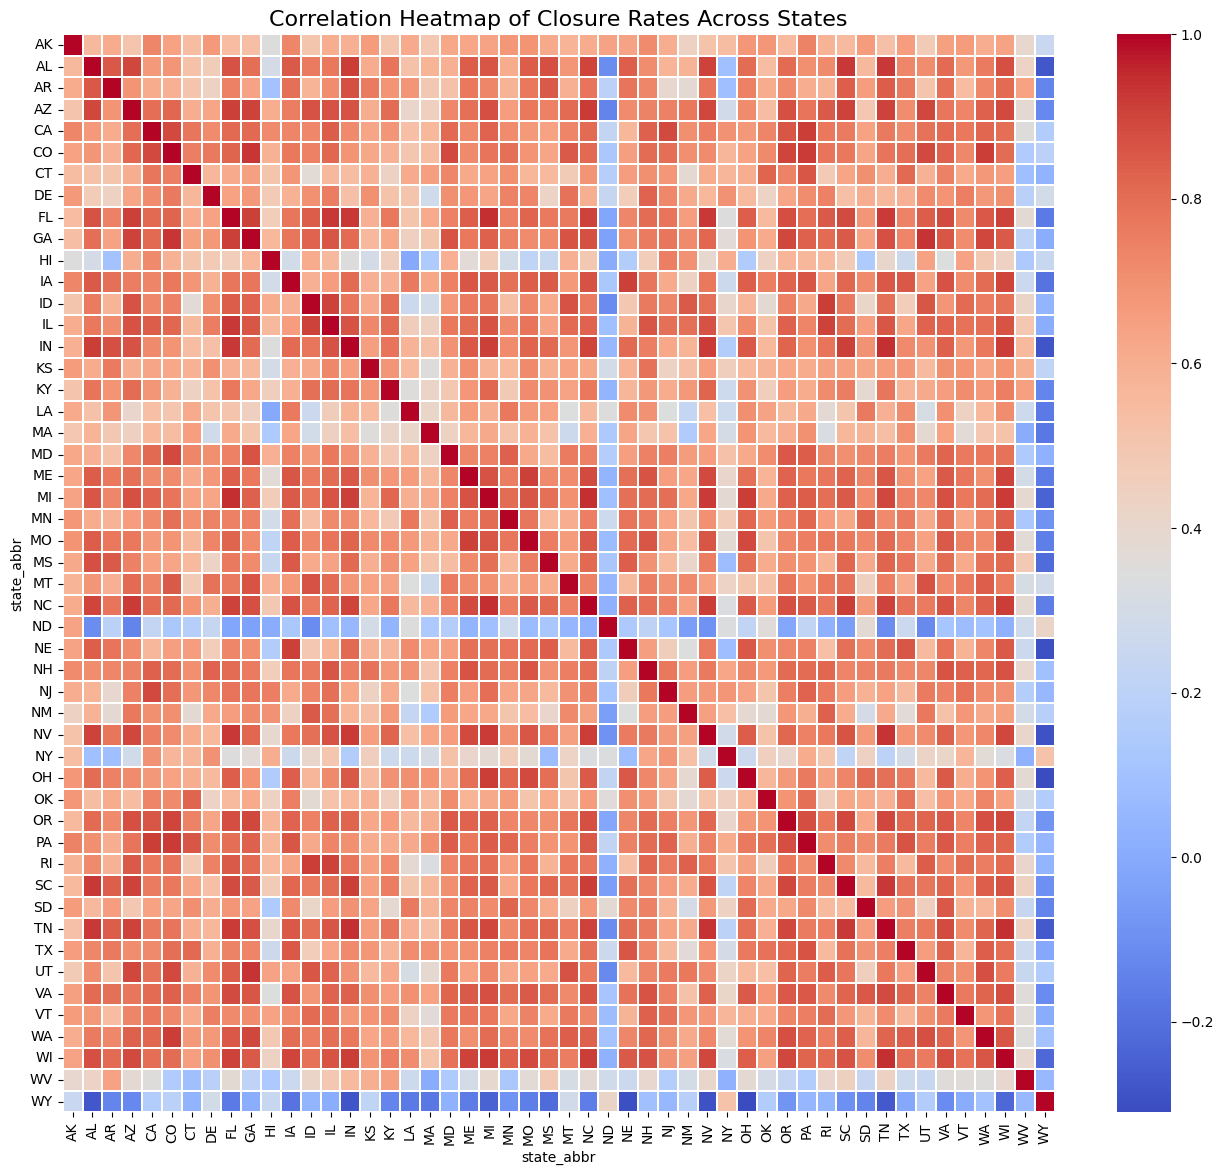

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creating a correlation heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.05)
plt.title('Correlation Heatmap of Closure Rates Across States', fontsize=16)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.show()

Converting correlation matrix to embeddings such that each state becomes an 8-dimensional vector.

In [ ]:
from sklearn.decomposition import TruncatedSVD

# Dimension for embeddings
embedding_dim = 8

# Getting Embeddings
svd = TruncatedSVD(
    n_components=embedding_dim,
    random_state=42
)

state_embeddings = svd.fit_transform(corr_matrix)

embedding_df = pd.DataFrame(
    state_embeddings,
    index=corr_matrix.index
)

embedding_df.columns = [
    f"state_emb_{i}"
    for i in range(embedding_dim)
]

print(embedding_df.head())

            state_emb_0  state_emb_1  state_emb_2  state_emb_3  state_emb_4  \
state_abbr                                                                    
AK             4.187938     0.141080     0.820395     0.425575    -0.016823   
AL             5.046534    -0.594175    -0.501698     0.046687     0.107087   
AR             4.618563    -0.789232     0.000038     0.475880     0.198157   
AZ             5.236387     0.092424    -0.618611    -0.087251     0.108395   
CA             5.151073     0.563463     0.216225    -0.063246     0.076466   

            state_emb_5  state_emb_6  state_emb_7  
state_abbr                                         
AK             0.083177     0.117391     0.159385  
AL             0.015573     0.073762    -0.035768  
AR            -0.061352    -0.011246    -0.092557  
AZ             0.014194     0.003479     0.031130  
CA             0.231869    -0.033220     0.024472  


### **State-State Business Closure Co-occurrence Network**

This analysis visualizes the **co-movement of business closure rates between states** using a network graph. States are connected by an edge if their business closure rates exhibit a strong positive Pearson correlation (above a set threshold, currently 0.8).

*   **Edges:** Represent strong positive correlations between state closure rates. The **thickness of the edge indicates the strength of this correlation**, with thicker edges signifying stronger co-movement.
*   **Nodes:** Represent individual states. The **size of each state's node reflects its total sum of firm deaths** over the years included in the analysis.
*   **Colors:** States are grouped and colored by detected communities, highlighting clusters of states that exhibit similar closure rate behaviors.

In [ ]:
%pip install python-louvain

In [ ]:
%pip install netgraph


Network Graph of State Co-occurrence based on Closure Rate Correlation


/usr/local/lib/python3.12/dist-packages/netgraph/_edge_layout.py:978: RuntimeWarning: invalid value encountered in divide
  displacement = compatibility * delta / distance_squared[..., None]
/usr/local/lib/python3.12/dist-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector


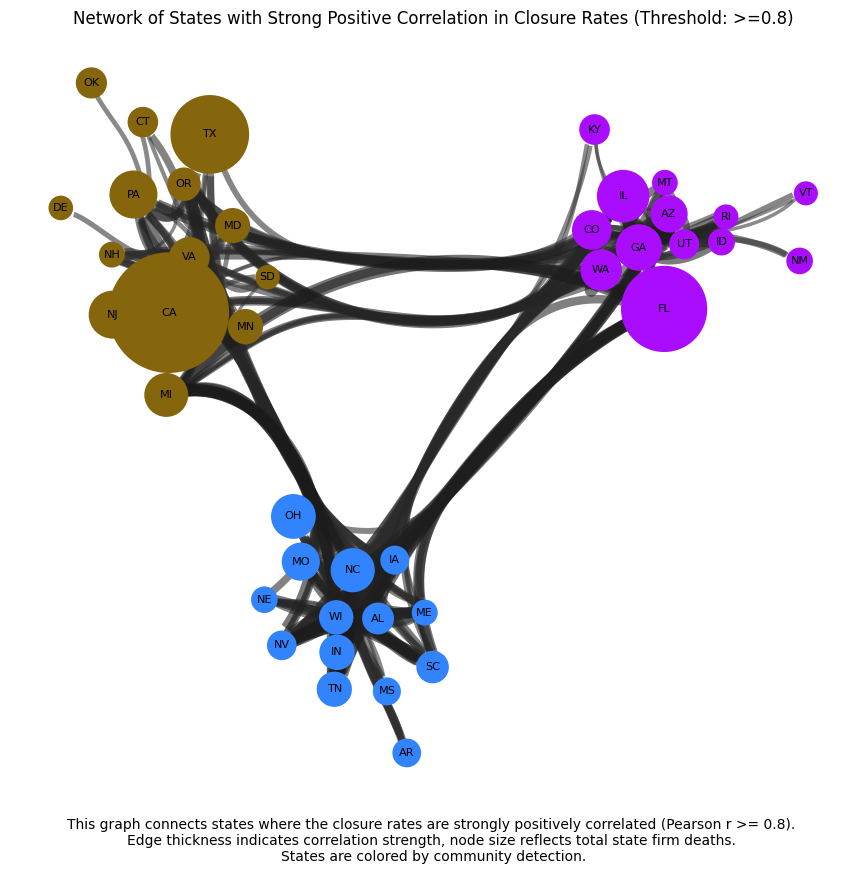

In [ ]:
import community.community_louvain as co
import networkx as nx
from collections import defaultdict
import matplotlib.pyplot as plt
from netgraph import Graph # Importing Graph from netgraph
import plotly.express as px

print("\nNetwork Graph of State Co-occurrence based on Closure Rate Correlation")

# Define a correlation threshold for creating edges
correlation_threshold = 0.8

# Create edges based on the correlation matrix
correlation_edges = []
for i in range(len(corr_matrix.index)):
    for j in range(i + 1, len(corr_matrix.columns)):
        state1 = corr_matrix.index[i]
        state2 = corr_matrix.columns[j]
        correlation_value = corr_matrix.iloc[i, j]
        if correlation_value >= correlation_threshold: # Only consider strong positive correlations
            correlation_edges.append({'u': state1, 'v': state2, 'weight': correlation_value})

# Calculating node sizes, indicating total firm deaths per state
state_total_closures = df.groupby('state_abbr')['firmdeath_firms'].sum()

# Creating the NetworkX graph
G = nx.Graph()
for edge in correlation_edges:
    G.add_edge(edge['u'], edge['v'], weight=edge['weight'])

# Filtering out states that are not connected in the graph (isolates)
isolates = list(nx.isolates(G))
G.remove_nodes_from(isolates)

# Performing community detection
partition = co.best_partition(G)
unique_communities = sorted(list(set(partition.values())))

# Mapping nodes to communities for netgraph's community layout
node_to_community = partition

# Generating colors for communities
community_colors_palette = px.colors.qualitative.Alphabet
community_color_map = {
    community_id: community_colors_palette[i % len(community_colors_palette)]
    for i, community_id in enumerate(unique_communities)
}

# Mapping each node to a color based on its community
node_color = {node: community_color_map[partition[node]] for node in G.nodes()}

# Scaling node sizes for netgraph
if not state_total_closures.empty and len(G.nodes()) > 0: # Check if there are nodes after filtering isolates
    # Filter state_total_closures to only include states present in the graph
    filtered_state_total_closures = state_total_closures[state_total_closures.index.isin(G.nodes())]

    min_closures = filtered_state_total_closures.min()
    max_closures = filtered_state_total_closures.max()

    if max_closures == min_closures:
        node_size_by = {state: 5 for state in G.nodes()}
    else:
        node_size_by = {state: 2 + 8 * (closures - min_closures) / (max_closures - min_closures)
                        for state, closures in filtered_state_total_closures.items()}
else:
    node_size_by = {} # Empty if no nodes or no closure data

# Creating edge widths based on correlation strength for netgraph
edge_widths = {}
for u, v, data in G.edges(data=True):
    # Scale correlation values (0.7 to 1.0) to a reasonable width range (e.g., 0.5 to 3.0)
    correlation_value = data['weight']
    scaled_width = 0.5 + (correlation_value - correlation_threshold) * (2.5 / (1.0 - correlation_threshold))
    edge_widths[(u,v)] = scaled_width


# Preparing node labels
node_labels = {node: node for node in G.nodes()} # Displaying state abbreviations as labels

fig, ax = plt.subplots(figsize=(12, 10)) # Adjusting figure size as needed

Graph(G,
      node_color=node_color, # Indicating the community each belongs to
      node_edge_width=0,     # Removing black border around nodes
      edge_width=edge_widths,        # Using calculated edge widths
      edge_alpha=0.6,        # Setting alpha
      node_layout='community', node_layout_kwargs=dict(node_to_community=node_to_community),
      node_size=node_size_by, # Using the calculated node sizes
      node_labels=node_labels,
      edge_layout='bundled',
      ax=ax,
)

ax.set_facecolor('white') # Setting the background to white

# Adding the title and explanation (static for netgraph)
ax.set_title(f'Network of States with Strong Positive Correlation in Closure Rates (Threshold: >={correlation_threshold})')
plt.text(0.5, -0.05,
         f"This graph connects states where the closure rates are strongly positively correlated (Pearson r >= {correlation_threshold}). \nEdge thickness indicates correlation strength, node size reflects total state firm deaths. \nStates are colored by community detection.",
         horizontalalignment='center',
         verticalalignment='center',
         transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.show()

### **State-Pair-Year Aggregation and Co-occurrence Target Definition**

This section prepares the data for the TCN model by transforming the state-year level data into a state-pair-year format. This involves creating unique pairs of states for each year and generating new features based on the differences between these paired states. A binary co-occurrence target is also defined based on the correlation of closure rates between states.

**Steps:**

**State-Year Base Aggregation:** The `df` is first aggregated to a `state_abbr`-`year` level (`state_level_df_base`). For each state and year, `firmdeath_firms` are summed, and other `base_features` (closure rates, economic indicators, lagged features, moving averages, YoY growth rates, and state embeddings) are averaged. This provides a baseline set of features for each state in each year.

**Generate Unique State Pairs:** All unique combinations of state pairs (e.g., AK-AL, AK-AR, but not AL-AK or AK-AK) are generated from the `state_level_df_base`.

**Create Initial State-Pair DataFrame:** An initial DataFrame (`state_pair_df`) is constructed containing all possible `year`-`state_abbr_1`-`state_abbr_2` combinations.

**Merge Features for State 1 and State 2:** The `state_level_df_base` is merged twice with `state_pair_df`: once to add features for `state_abbr_1` (suffixed with `_1`) and once for `state_abbr_2` (suffixed with `_2`). This brings all relevant features for both states in a pair into a single row for each year.

**Calculate Difference Features:** For a defined set of `features_to_difference` (excluding `firmdeath_firms`), new features are created representing the absolute difference between the values for `state_abbr_1` and `state_abbr_2` (e.g., `closure_rate_diff = closure_rate_1 - closure_rate_2`).

**Define Co-occurrence Target:** A binary target variable, `cooccurrence_target_pair`, is created. It is set to `1` if the Pearson correlation coefficient between `state_abbr_1` and `state_abbr_2` in the `corr_matrix` (from previous EDA) is greater than or equal to a `correlation_threshold_for_target` (currently 0.8); otherwise, it's `0`. This indicates whether a strong co-movement in closure rates exists between the state pair.

**Final Cleaning and Renaming:** Any rows with missing values are dropped, and the resulting `state_pair_df` is renamed to `state_level_df` to be used in subsequent modeling steps.

In [ ]:
import pandas as pd
import numpy as np
from itertools import combinations

# --- New aggregation: State-pair-year level with difference features and co-occurrence target ---
print("Generating state-pair-year data with difference features and co-occurrence target...")

# 1. Aggregate df to state-year level (base features for each state)
base_features = [
    'closure_rate',
    'closure_rate_firms',
    'job_destruction_rate',
    'net_job_creation_rate',
    'reallocation_rate',
    'income',
    'population',
    'employment_density',
    'emp',
    'lag1_closure_rate',
    'lag2_closure_rate',
    'ma3_closure_rate',
    'ma3_job_destruction_rate',
    'income_yoy',
    'population_yoy',
    'employment_yoy'
]

agg_funcs = {
    'firmdeath_firms': 'sum' # Keep firmdeath_firms for potential future use or context
}
for col in base_features:
    if col not in agg_funcs:
        agg_funcs[col] = 'mean'

state_level_df_base = df.groupby(['state_abbr', 'year']).agg(agg_funcs).reset_index()
state_level_df_base = state_level_df_base.dropna() # Drop NaNs that might arise from initial feature engineering

print("State-level base aggregation complete. Shape:", state_level_df_base.shape)

# 2. Generate unique state pairs
unique_states = state_level_df_base['state_abbr'].unique()
state_pairs_list = list(combinations(unique_states, 2)) # Get unique combinations (A,B) not (B,A) or (A,A)

# 3. Create initial DataFrame of state pairs and years
all_years = state_level_df_base['year'].unique()

state_pair_data = []
for year in all_years:
    for s1, s2 in state_pairs_list:
        state_pair_data.append({'year': year, 'state_abbr_1': s1, 'state_abbr_2': s2})

state_pair_df = pd.DataFrame(
    state_pair_data)

# 4. Merge features for state_1
state_pair_df = state_pair_df.merge(state_level_df_base,
                                    left_on=['year', 'state_abbr_1'],
                                    right_on=['year', 'state_abbr'],
                                    how='inner',
                                    suffixes=('_1', ''))
state_pair_df = state_pair_df.drop(columns=['state_abbr'])

# 5. Merge features for state_2
state_pair_df = state_pair_df.merge(state_level_df_base,
                                    left_on=['year', 'state_abbr_2'],
                                    right_on=['year', 'state_abbr'],
                                    how='inner',
                                    suffixes=('_1', '_2'))
state_pair_df = state_pair_df.drop(columns=['state_abbr'])

# 6. Calculate difference features
# Features that are suitable for differencing (not firmdeath_firms or state embeddings)
features_to_difference = [f for f in base_features if f not in ['firmdeath_firms'] and not f.startswith('state_emb_')]

for feature in features_to_difference:
    state_pair_df[f'{feature}_diff'] = state_pair_df[f'{feature}_1'] - state_pair_df[f'{feature}_2']

# 7. Define Co-occurrence Target based on overall corr_matrix and threshold
correlation_threshold_for_target = 0.8 # As used in network graph

state_pair_df['cooccurrence_target_pair'] = state_pair_df.apply(
    lambda row:
        1 if row['state_abbr_1'] in corr_matrix.index and row['state_abbr_2'] in corr_matrix.columns and \
             corr_matrix.loc[row['state_abbr_1'], row['state_abbr_2']] >= correlation_threshold_for_target
        else 0,
    axis=1
)

# 8. Final Cleaning
state_pair_df = state_pair_df.dropna()

# Renaming the final DataFrame for clarity (as it will be the new 'state_level_df' for subsequent steps)
state_level_df = state_pair_df

print("State-pair-year aggregated DataFrame (state_level_df) generation complete. Head:")
display(state_level_df.head())
print(f"Final state_level_df shape: {state_level_df.shape}")

Generating state-pair-year data with difference features and co-occurrence target...
State-level base aggregation complete. Shape: (1200, 19)
State-pair-year aggregated DataFrame (state_level_df) generation complete. Head:


,year,state_abbr_1,state_abbr_2,firmdeath_firms_1,closure_rate_1,closure_rate_firms_1,job_destruction_rate_1,net_job_creation_rate_1,reallocation_rate_1,income_1,...,employment_density_diff,emp_diff,lag1_closure_rate_diff,lag2_closure_rate_diff,ma3_closure_rate_diff,ma3_job_destruction_rate_diff,income_yoy_diff,population_yoy_diff,employment_yoy_diff,cooccurrence_target_pair
0,2000-01-01,AK,AL,766.1625,0.067787,0.070949,18.456159,-0.718056,23.640876,90360.0,...,-0.104579,-7912.127293,-0.005385,-0.000161,-0.003309,1.216617,0.0,0.0,-5.543107,0
1,2000-01-01,AK,AR,766.1625,0.067787,0.070949,18.456159,-0.718056,23.640876,90360.0,...,-0.108175,-4282.744355,-0.009557,0.002407,-0.005312,2.825176,0.0,0.0,-3.408965,0
2,2000-01-01,AK,AZ,766.1625,0.067787,0.070949,18.456159,-0.718056,23.640876,90360.0,...,-0.083086,-9254.720826,-0.009058,-0.002188,-0.005621,0.200940,0.0,0.0,1.550687,0
3,2000-01-01,AK,CA,766.1625,0.067787,0.070949,18.456159,-0.718056,23.640876,90360.0,...,-0.083427,-67794.326123,-0.004280,0.006975,-0.000146,1.909011,0.0,0.0,-3.923771,0
4,2000-01-01,AK,CO,766.1625,0.067787,0.070949,18.456159,-0.718056,23.640876,90360.0,...,-0.468504,-9229.811503,-0.000532,0.010898,0.002839,0.303851,0.0,0.0,-1.301045,0


Final state_level_df shape: (29400, 54)


### **TCN Model Implementation: Data Preparation**

Preparing `state_level_df` by transforming it into sequential data. Each sequence will represent a time series of features for a given state pair, leading up to a target `cooccurrence_target_pair`.

In [ ]:
# Import libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:
# Feature and Target Selection

# Identifying all difference features
X_cols = [col for col in state_level_df.columns if col.endswith('_diff')]

y_col = 'cooccurrence_target_pair'

# Drop rows where any of the selected columns might be NaN (should have been handled by previous dropna, but good to re-confirm)
current_df = state_level_df[X_cols + [y_col] + ['year', 'state_abbr_1', 'state_abbr_2']].dropna().copy()

# Scale numerical features
scaler = StandardScaler()
current_df[X_cols] = scaler.fit_transform(current_df[X_cols])

print(f"Selected {len(X_cols)} features for X.")
print(f"Data shape after feature selection and scaling: {current_df.shape}")
print(current_df[X_cols].head())

Selected 16 features for X.
Data shape after feature selection and scaling: (29400, 20)
   closure_rate_diff  closure_rate_firms_diff  job_destruction_rate_diff  \
0          -0.431212                -0.573140                   0.439633   
1          -0.767788                -0.799917                   0.914558   
2          -0.525689                -0.787136                  -0.056571   
3          -0.336078                -0.519338                   0.362289   
4          -0.238011                -0.367237                  -0.032161   

   net_job_creation_rate_diff  reallocation_rate_diff  income_diff  \
0                    0.061628               -0.416487     1.766172   
1                   -0.242459                0.247262     2.360204   
2                    0.069700               -0.741653     1.314125   
3                   -0.627651               -1.705987     0.584175   
4                    0.029349               -0.671653     0.436728   

   population_diff  employment_den

In [ ]:
# Creating Sequences for TCN

sequence_length = 3

X_sequences = []
y_sequences = []
state_pair_indices = []

# Grouping by state pairs and generate sequences
for (s1, s2), group in current_df.groupby(['state_abbr_1', 'state_abbr_2']):
    # Sorting by year to ensure correct sequence order
    group = group.sort_values('year').reset_index(drop=True)

    if len(group) >= sequence_length:
        for i in range(len(group) - sequence_length + 1):
            # Features for the sequence_length years
            X_sequences.append(group.iloc[i : i + sequence_length][X_cols].values)
            # Target for the *last* year in the sequence
            y_sequences.append(group.iloc[i + sequence_length - 1][y_col])
            state_pair_indices.append((s1, s2, group.iloc[i + sequence_length - 1]['year']))

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

print(f"Generated {len(X_sequences)} sequences.")
print(f"X_sequences shape: {X_sequences.shape}")
print(f"y_sequences shape: {y_sequences.shape}")

# Check for target distribution before splitting
print("Target distribution in full dataset:")
print(pd.Series(y_sequences).value_counts(normalize=True))

Generated 26950 sequences.
X_sequences shape: (26950, 3, 16)
y_sequences shape: (26950,)
Target distribution in full dataset:
0    0.778776
1    0.221224
Name: proportion, dtype: float64


### **TCN Model Implementation: Data Splitting (Train, Validation, Test)**

Splitting the data for time-series models requires careful consideration to avoid data leakage. stratified splitting will ensure that the proportions of `cooccurrence_target_pair` (0s and 1s) are maintained across the training, validation, and test sets. This is crucial for imbalanced datasets.

To prevent leakage between state pairs, we will first split based on the unique state pairs and then assign their corresponding sequences to the respective sets.

In [ ]:
# Getting unique state pairs and their corresponding average target for stratification
unique_state_pairs = current_df[['state_abbr_1', 'state_abbr_2']].drop_duplicates().values

# Creating a mapping from (s1, s2, year) to its index in X_sequences/y_sequences
sequence_map = {(s1, s2, year): i for i, (s1, s2, year) in enumerate(state_pair_indices)}

# Creating a DataFrame for unique state pairs with an aggregated target for stratification
# Using the mean of the cooccurrence target for each state pair to stratify
state_pair_target_means = state_level_df.groupby(['state_abbr_1', 'state_abbr_2'])[y_col].mean().reset_index()
state_pair_target_means['stratify_target'] = (state_pair_target_means[y_col] > 0).astype(int) # Binary for stratification

# Performing stratified train-test split on unique state pairs
s_train_pairs, s_test_pairs, _, _ = train_test_split(
    unique_state_pairs, state_pair_target_means['stratify_target'], test_size=0.2, random_state=42, stratify=state_pair_target_means['stratify_target']
)

# Further split training pairs into train and validation pairs
s_train_pairs, s_val_pairs, _, _ = train_test_split(
    s_train_pairs, state_pair_target_means.loc[state_pair_target_means[['state_abbr_1', 'state_abbr_2']].apply(tuple, 1).isin(map(tuple, s_train_pairs)), 'stratify_target'],
    test_size=0.25, random_state=42, stratify=state_pair_target_means.loc[state_pair_target_means[['state_abbr_1', 'state_abbr_2']].apply(tuple, 1).isin(map(tuple, s_train_pairs)), 'stratify_target']
)

# Function to extract sequences for given state pairs
def get_sequences_for_pairs(pairs_list):
    X = []
    y = []
    for s1, s2 in pairs_list:
        for i, (sp1, sp2, year) in enumerate(state_pair_indices):
            if (s1, s2) == (sp1, sp2):
                X.append(X_sequences[i])
                y.append(y_sequences[i])
    return np.array(X), np.array(y)

X_train, y_train = get_sequences_for_pairs(s_train_pairs)
X_val, y_val = get_sequences_for_pairs(s_val_pairs)
X_test, y_test = get_sequences_for_pairs(s_test_pairs)

print(f"Training sequences: X_train.shape={X_train.shape}, y_train.shape={y_train.shape}")
print(f"Validation sequences: X_val.shape={X_val.shape}, y_val.shape={y_val.shape}")
print(f"Test sequences: X_test.shape={X_test.shape}, y_test.shape={y_test.shape}")

print("\nTarget distribution in Training set:")
print(pd.Series(y_train).value_counts(normalize=True))
print("\nTarget distribution in Validation set:")
print(pd.Series(y_val).value_counts(normalize=True))
print("\nTarget distribution in Test set:")
print(pd.Series(y_test).value_counts(normalize=True))

Training sequences: X_train.shape=(16170, 3, 16), y_train.shape=(16170,)
Validation sequences: X_val.shape=(5390, 3, 16), y_val.shape=(5390,)
Test sequences: X_test.shape=(5390, 3, 16), y_test.shape=(5390,)

Target distribution in Training set:
0    0.780952
1    0.219048
Name: proportion, dtype: float64

Target distribution in Validation set:
0    0.771429
1    0.228571
Name: proportion, dtype: float64

Target distribution in Test set:
0    0.779592
1    0.220408
Name: proportion, dtype: float64


### **TCN Model Implementation: TCN Architecture**

Temporal Convolutional Networks (TCNs) are a class of neural networks designed for sequence modeling tasks, offering advantages over traditional RNNs like LSTMs in terms of parallelization and longer memory. Key features of the TCN architecture include:

*   **Dilated Convolutions:** Allow the receptive field to grow exponentially with network depth, capturing long-range dependencies without increasing the number of parameters or losing resolution.
*   **Causal Convolutions:** Ensure that predictions at a given time step only depend on past and current inputs, not future ones, making them suitable for time-series forecasting.
*   **Residual Connections:** Help in training deeper networks by allowing gradients to flow more easily, preventing vanishing gradient problems and improving performance.

In [ ]:
# Define the TCN model

input_shape = X_train.shape[1:]  # (sequence_length, num_features)
num_features = input_shape[1]

def build_tcn_model(input_shape, num_classes=1):
    inputs = keras.Input(shape=input_shape)
    x = inputs

    # TCN block with dilated convolutions and residual connections
    num_filters = 64
    kernel_size = 2
    dropout_rate = 0.2

    for i in range(3): # Three TCN blocks
        dilation_rate = 2**i

        # Residual block
        res_x = x

        # First convolutional layer
        x = layers.Conv1D(
            filters=num_filters,
            kernel_size=kernel_size,
            dilation_rate=dilation_rate,
            padding='causal',
            activation='relu',
            kernel_initializer='he_normal'
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout_rate)(x)

        # Second convolutional layer
        x = layers.Conv1D(
            filters=num_filters,
            kernel_size=kernel_size,
            dilation_rate=dilation_rate,
            padding='causal',
            activation='relu',
            kernel_initializer='he_normal'
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout_rate)(x)

        # 1x1 convolution for residual connection if dimensions don't match
        if res_x.shape[-1] != num_filters:
            res_x = layers.Conv1D(filters=num_filters, kernel_size=1, padding='same')(res_x)

        x = layers.Add()([res_x, x])
        x = layers.Activation('relu')(x)

    x = layers.GlobalAveragePooling1D()(x) # Aggregate sequence output
    outputs = layers.Dense(num_classes, activation='sigmoid')(x) # Binary classification

    model = keras.Model(inputs, outputs)
    return model

# Build the model
tcn_model = build_tcn_model(input_shape)

tcn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 3, 16)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 3, 64)     │      2,112 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 3, 64)     │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 3, 64)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 3, 64)     │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 64)     │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 3, 64)     │      1,088 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 3, 64)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 3, 64)     │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 3, 64)     │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 3, 64)     │      8,256 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 64)     │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 3, 64)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 3, 64)     │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 64)     │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 3, 64)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 3, 64)     │          0 │ activation[0][0], │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 3, 64)     │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 3, 64)     │      8,256 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 64)     │        256 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 46,081 (180.00 KB)

 Trainable params: 45,313 (177.00 KB)

 Non-trainable params: 768 (3.00 KB)

Total: 16170, Positive: 3542, Negative: 12628
Class weights: {0: np.float64(0.6402439024390244), 1: np.float64(2.282608695652174)}
Epoch 1/50
506/506 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.5835 - auc: 0.6674 - loss: 0.6695 - val_accuracy: 0.5117 - val_auc: 0.6816 - val_loss: 0.7199
Epoch 2/50
506/506 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.6445 - auc: 0.7398 - loss: 0.5980 - val_accuracy: 0.5690 - val_auc: 0.7055 - val_loss: 0.6975
Epoch 3/50
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6634 - auc: 0.7635 - loss: 0.5769 - val_accuracy: 0.5978 - val_auc: 0.7107 - val_loss: 0.6839
Epoch 4/50
506/506 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6790 - auc: 0.7786 - loss: 0.5610 - val_accuracy: 0.6226 - val_auc: 0.7337 - val_loss: 0.6600
Epoch 5/50
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6890 - auc: 0.7914 - loss: 0.5454 - val_accuracy: 0.6451 - val_auc: 0.7371 - val_loss: 0.6364
Epoch 6/50
506/506 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy

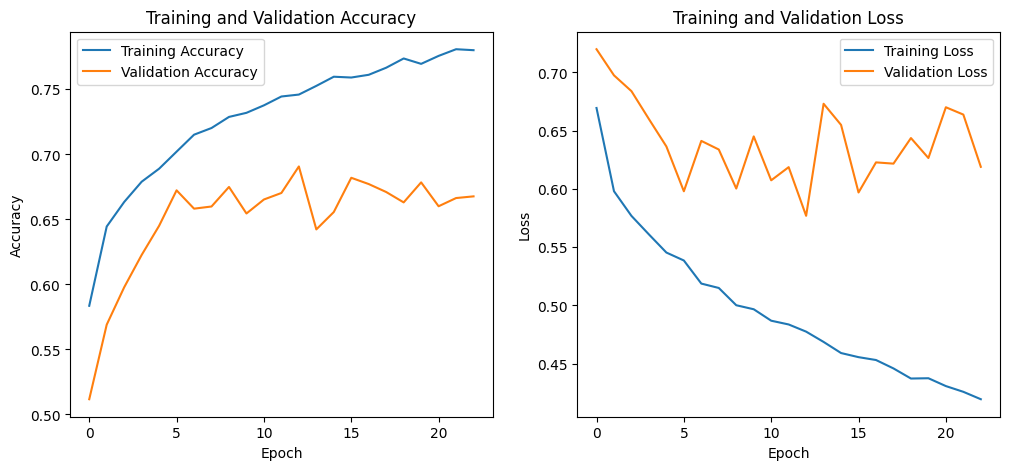

In [ ]:
# Compile and Train TCN Model

# Handling class imbalance by calculating class weights
neg, pos = np.bincount(y_train.astype(int))
total = neg + pos

print(f'Total: {total}, Positive: {pos}, Negative: {neg}')
initial_bias = np.log([pos/neg]) # For potential use in final layer initializer

# Scaling by total to make the sum of weights equal to 1
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)

class_weight = {0: weight_for_0, 1: weight_for_1}
print(f'Class weights: {class_weight}')

# Compile the model
tcn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.BinaryAccuracy(name='accuracy'),
        keras.metrics.AUC(name='auc')
    ]
)

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, mode='min'
)

# Train the model
history = tcn_model.fit(
    X_train, y_train,
    epochs=50, # Adjust epochs as needed
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    class_weight=class_weight
)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### **TCN Model Implementation: Model Evaluation**

Evaluating the TCN model involved assessing its performance on the unseen test set using a the following metrics.

*   **Accuracy:** Overall correctness of predictions.
*   **Precision:** Proportion of true positive predictions among all positive predictions.
*   **Recall (Sensitivity):** Proportion of true positive predictions among all actual positive instances.
*   **F1-Score:** Harmonic mean of precision and recall, balancing both.
*   **AUC-ROC:** Area Under the Receiver Operating Characteristic curve, measuring the model's ability to distinguish between classes.
*   **Confusion Matrix:** A table summarizing the number of correct and incorrect predictions made by a classification model.

Test Loss: 0.6316
Test Accuracy: 0.6558
Test AUC: 0.7151
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.65      0.75      4202
           1       0.35      0.67      0.46      1188

    accuracy                           0.66      5390
   macro avg       0.61      0.66      0.60      5390
weighted avg       0.76      0.66      0.68      5390



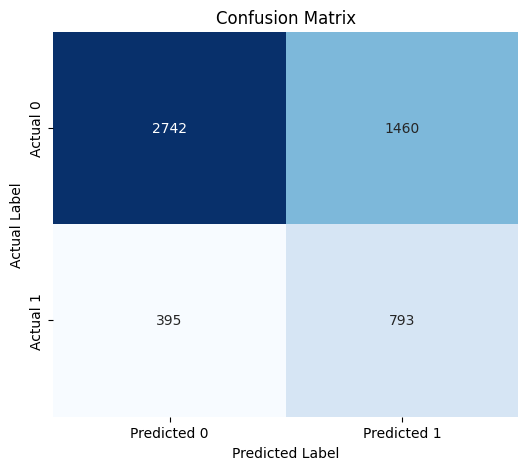

In [ ]:
# Evaluate the model on the test set
loss, accuracy, auc = tcn_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test AUC: {auc:.4f}")

# Make predictions
y_pred_proba = tcn_model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### **TCN Model Implementation: Feature Importance**

Permutation importance works by shuffling a single feature's values in the validation set and observing how much the model's performance (e.g., AUC score) drops. A larger drop indicates a more important feature.



169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Calculating permutation feature importance...
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
  - Feature 'closure_rate_diff': Importance = 0.0093
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
  - Feature 'closure_rate_firms_diff': Importance = 0.0186
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
  - Feature 'job_destruction_rate_diff': Importance = 0.0100
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  - Feature 'net_job_creation_rate_diff': Importance = 0.0046
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  - Feature 'reallocation_rate_diff': Importance = 0.0777
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  - Feature 'income_diff': Importance = 0.0526
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  - Feature 'population_diff': Importance = 0.0200
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  - Feature 'employment_density_diff': Importance = 0.0405
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  - Feature 'emp_diff': Importance = 0.0010
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  - Featu

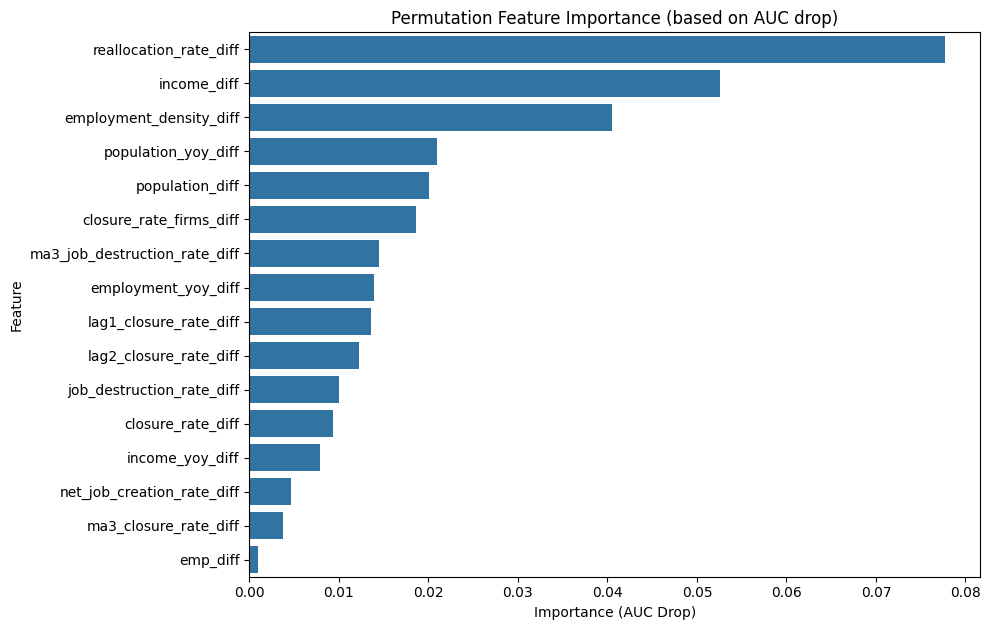

,Feature,Importance
0,reallocation_rate_diff,0.077735
1,income_diff,0.052571
2,employment_density_diff,0.040530
3,population_yoy_diff,0.021012
4,population_diff,0.020033
5,closure_rate_firms_diff,0.018557
6,ma3_job_destruction_rate_diff,0.014488
7,employment_yoy_diff,0.013946
8,lag1_closure_rate_diff,0.013640
9,lag2_closure_rate_diff,0.012197


In [ ]:
# Calculate Permutation Feature Importance

# Baseline performance
original_auc = roc_auc_score(y_test, tcn_model.predict(X_test))

feature_importances = {}

print("Calculating permutation feature importance...")
for i, feature_name in enumerate(X_cols):
    # Create a copy of the test data
    X_test_permuted = X_test.copy()

    # Permute the values of the current feature across all time steps in the sequences
    # For TCN, we permute the entire feature channel across all sequences and timesteps
    # X_test_permuted[:, :, i] = np.random.permutation(X_test_permuted[:, :, i].flatten()).reshape(X_test_permuted[:, :, i].shape)
    # A simpler approach: permute column 'i' values for all sequences and all time steps
    X_test_permuted[:, :, i] = np.random.permutation(X_test_permuted[:, :, i]) # Shuffles within each timestep/sequence

    # Predict with permuted data
    permuted_auc = roc_auc_score(y_test, tcn_model.predict(X_test_permuted))

    # Calculate importance as the drop in AUC
    importance = abs(original_auc - permuted_auc)
    feature_importances[feature_name] = importance
    print(f"  - Feature '{feature_name}': Importance = {importance:.4f}")

# Sort and visualize feature importances
sorted_importance = sorted(feature_importances.items(), key=lambda item: item[1], reverse=True)

importance_df = pd.DataFrame(sorted_importance, columns=['Feature', 'Importance'])

plt.figure(figsize=(10, len(X_cols) * 0.4))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Permutation Feature Importance (based on AUC drop)')
plt.xlabel('Importance (AUC Drop)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

display(importance_df)

## **Sector-Sector Co-Occurrence Modeling**

### **Sector-Sector Business Closure Rates Correlation**

This analysis checks the association between firm death rates (`closure_rate_firms`) among pairs of sectors for co-movement.

In [8]:
# rows = year and columns = sector
sector_panel = (
    df.groupby(["year","sector_name"])["closure_rate"]
      .mean()
      .unstack()
)
# Correlation Matrix
corr_matrix_sectors = sector_panel.corr(method="pearson")
print("Correlation Matrix (first 5 rows and columns):")
display(corr_matrix_sectors.head())

Correlation Matrix (first 5 rows and columns):


sector_name,Accommodation and Food Services,Administrative and Support and Waste Management and Remediation Services,"Agriculture, Forestry, Fishing and Hunting","Arts, Entertainment, and Recreation",Construction,Educational Services,Finance and Insurance,Health Care and Social Assistance,Information,Management of Companies and Enterprises,Manufacturing,"Mining, Quarrying, and Oil and Gas Extraction",Other Services (except Public Administration),"Professional, Scientific, and Technical Services",Real Estate and Rental and Leasing,Retail Trade,Transportation and Warehousing,Utilities,Wholesale Trade
sector_name,,,,,,,,,,,,,,,,,,,
Accommodation and Food Services,1.000000,0.708784,0.780978,0.787030,0.638277,0.494764,0.634389,-0.078753,0.829150,0.525022,0.728202,-0.133813,0.796882,0.322672,0.652782,0.948985,0.661372,0.120391,0.601439
Administrative and Support and Waste Management and Remediation Services,0.708784,1.000000,0.823090,0.581112,0.650693,0.313525,0.699120,0.075822,0.885184,0.650704,0.811934,-0.143469,0.708967,0.690291,0.718979,0.760105,0.879202,0.531373,0.813702
"Agriculture, Forestry, Fishing and Hunting",0.780978,0.823090,1.000000,0.662173,0.531717,0.554311,0.612692,0.094772,0.792934,0.774205,0.584197,-0.398339,0.857333,0.518838,0.688374,0.769590,0.776959,0.522696,0.532381
"Arts, Entertainment, and Recreation",0.787030,0.581112,0.662173,1.000000,0.713133,0.792035,0.690763,-0.040872,0.616677,0.308003,0.682377,0.069651,0.760768,0.495939,0.690939,0.801644,0.574964,0.034954,0.639895
Construction,0.638277,0.650693,0.531717,0.713133,1.000000,0.406847,0.921852,-0.186696,0.600663,0.179246,0.856407,0.050146,0.503081,0.535704,0.863938,0.724399,0.592263,-0.194344,0.713746


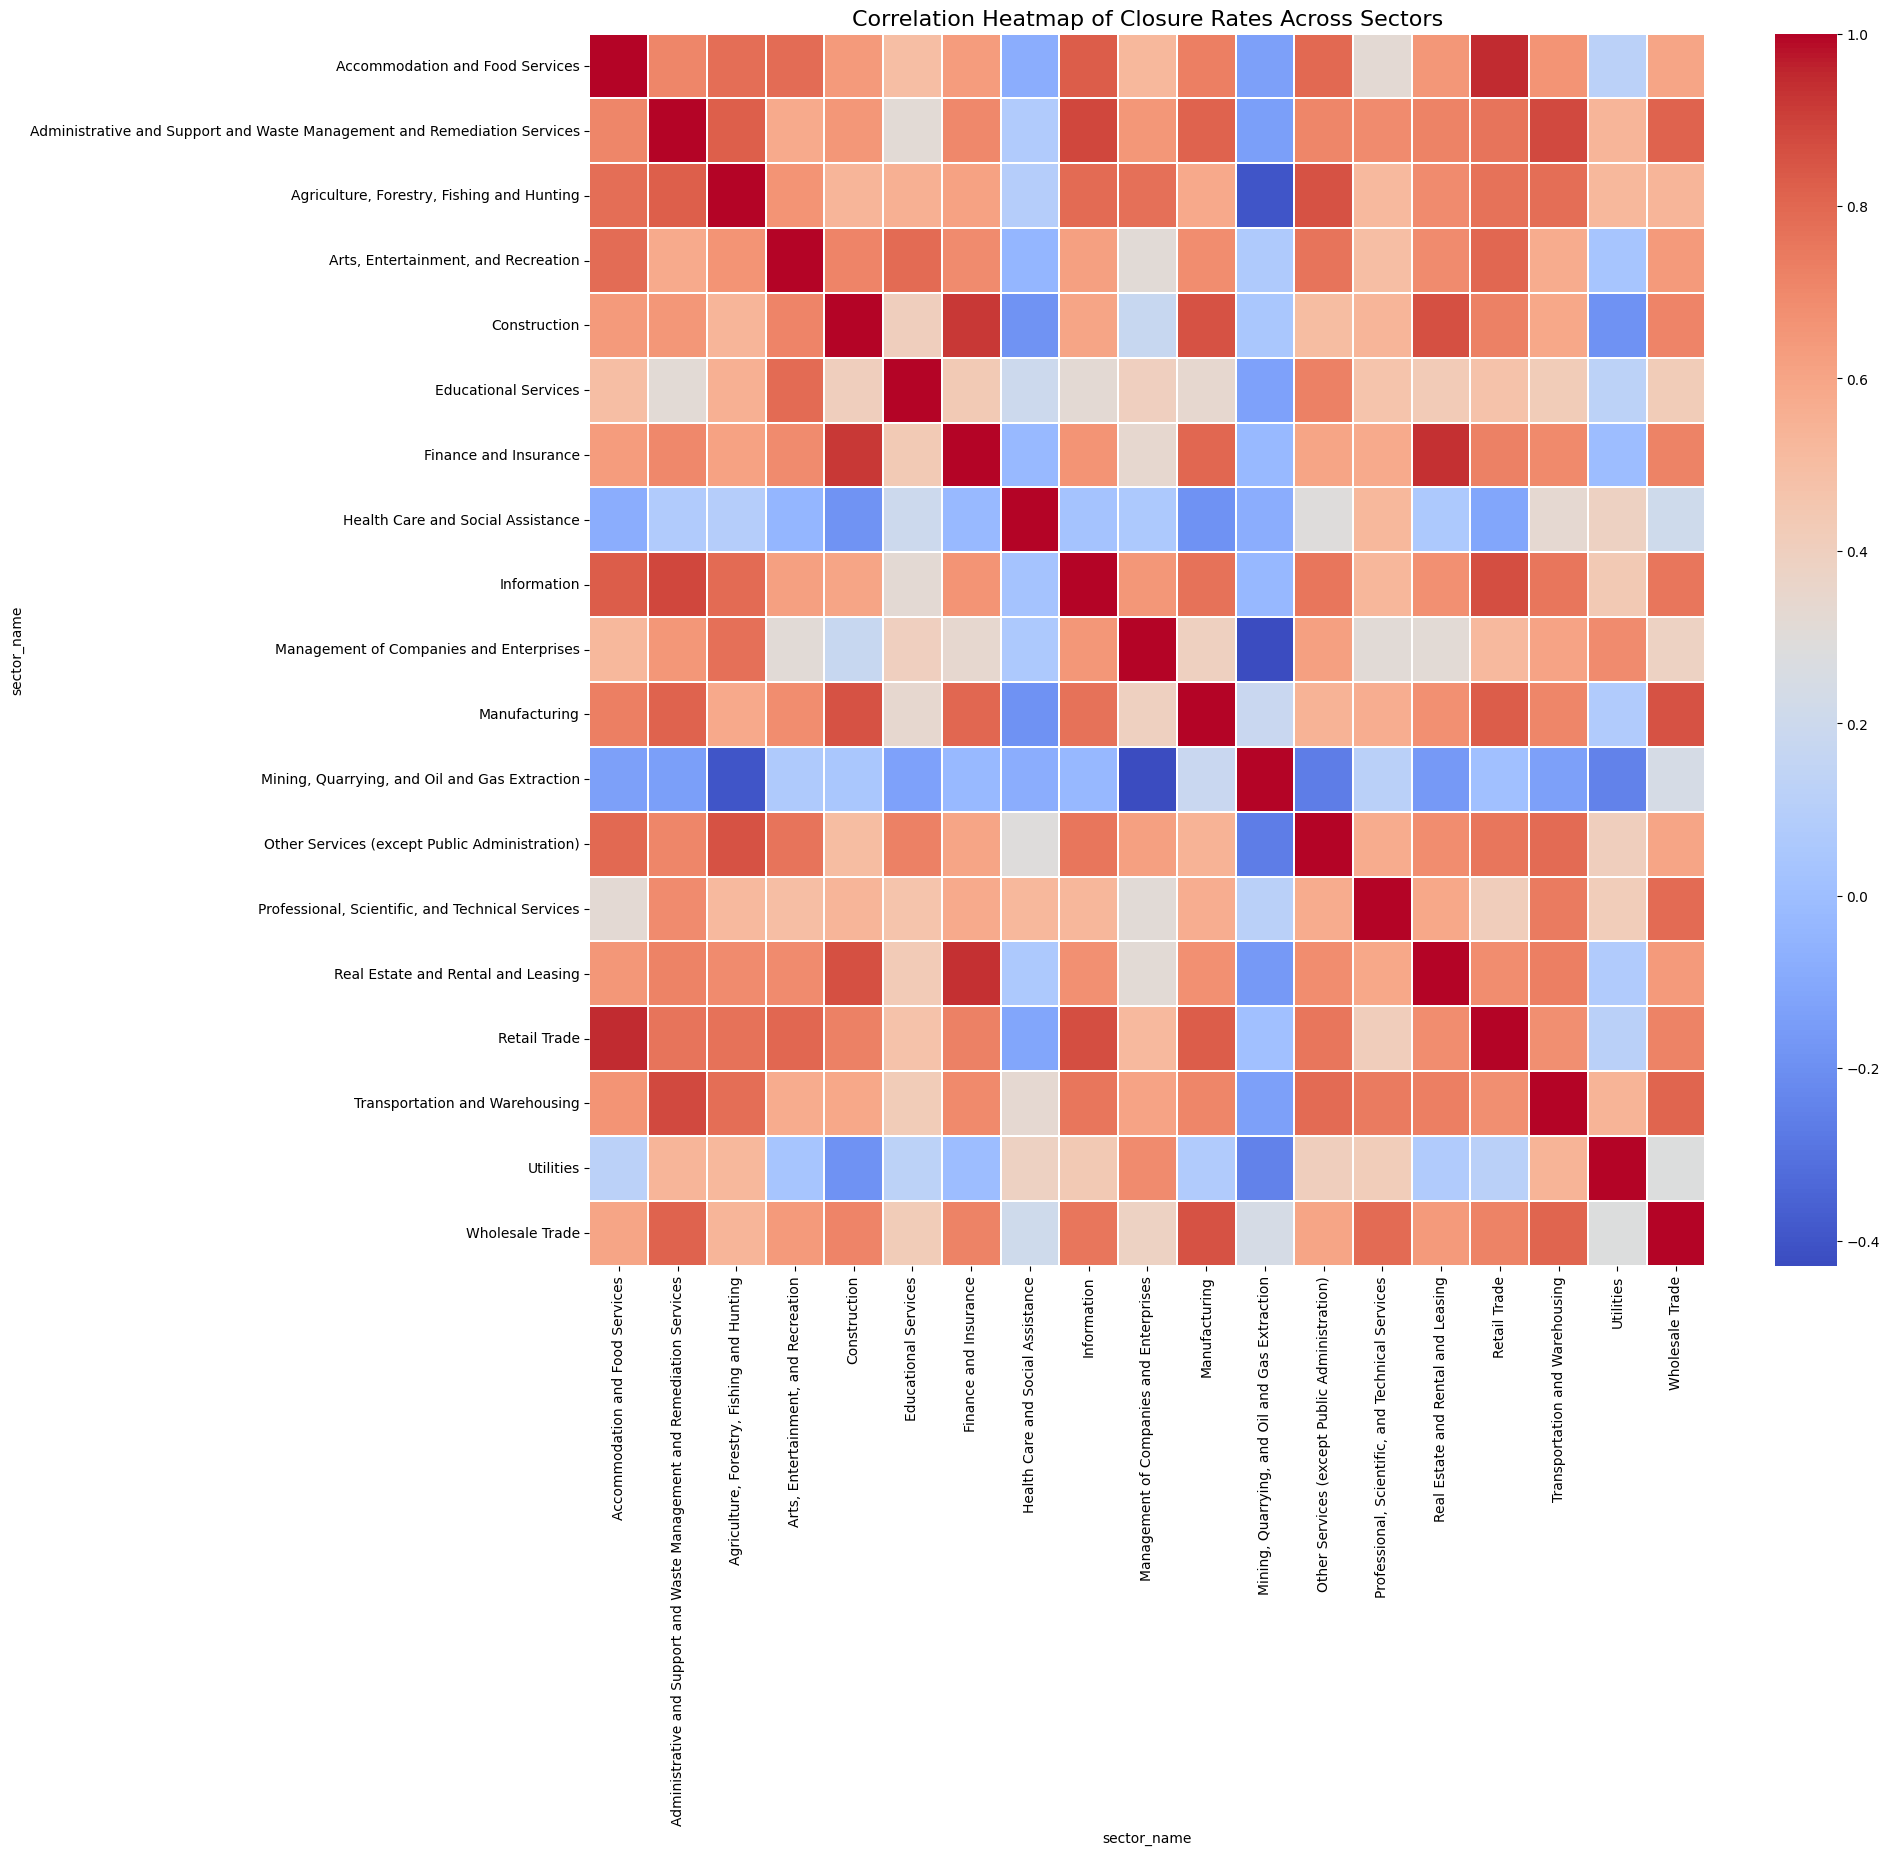

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creating a correlation heatmap for sectors
plt.figure(figsize=(18, 16)) # Adjusted for more sectors
sns.heatmap(corr_matrix_sectors, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.05)
plt.title('Correlation Heatmap of Closure Rates Across Sectors', fontsize=16)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.show()

### **Converting correlation matrix to embeddings**

Converting the sector correlation matrix into lower-dimensional embeddings, where each sector becomes an 8-dimensional vector.

In [10]:
from sklearn.decomposition import TruncatedSVD

# Dimension for embeddings
embedding_dim = 8 # Consistent with state embeddings

# Getting Embeddings
svd_sectors = TruncatedSVD(
    n_components=embedding_dim,
    random_state=42
)

sector_embeddings = svd_sectors.fit_transform(corr_matrix_sectors)

embedding_df_sectors = pd.DataFrame(
    sector_embeddings,
    index=corr_matrix_sectors.index
)

embedding_df_sectors.columns = [
    f"sector_emb_{i}"
    for i in range(embedding_dim)
]

print("Sector Embeddings (first 5 rows):")
display(embedding_df_sectors.head())

Sector Embeddings (first 5 rows):


,sector_emb_0,sector_emb_1,sector_emb_2,sector_emb_3,sector_emb_4,sector_emb_5,sector_emb_6,sector_emb_7
sector_name,,,,,,,,
Accommodation and Food Services,2.806273,-0.184149,-0.430082,0.024956,0.195047,0.219150,-0.036457,-0.020305
Administrative and Support and Waste Management and Remediation Services,3.001422,0.229407,0.056420,-0.364135,-0.087420,-0.029430,0.003197,-0.076277
"Agriculture, Forestry, Fishing and Hunting",2.876843,0.489523,-0.361814,0.038987,-0.025247,-0.008643,0.062176,-0.027820
"Arts, Entertainment, and Recreation",2.682777,-0.424349,-0.100246,0.418466,0.259263,-0.047740,0.067092,-0.057755
Construction,2.591175,-0.845526,0.032424,0.039064,-0.268370,-0.072667,-0.023327,-0.005451


### **Sector-Sector Business Closure Co-occurrence Network**

This analysis visualizes the **co-movement of business closure rates between sectors** using a network graph. Sectors are connected by an edge if their business closure rates exhibit a strong positive Pearson correlation (above a set threshold, currently 0.8).

*   **Edges:** Represent strong positive correlations between sector closure rates. The **thickness of the edge indicates the strength of this correlation**, with thicker edges signifying stronger co-movement.
*   **Nodes:** Represent individual sectors, labeled by their 2-digit NAICS codes. The **size of each sector's node reflects its total sum of firm deaths** over the years included in the analysis.
*   **Colors:** Sectors are grouped and colored by detected communities, highlighting clusters of sectors that exhibit similar closure rate behaviors.

In [12]:
%pip install netgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.7/96.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 372.3/372.3 kB 14.3 MB/s eta 0:00:00



Network Graph of Sector Co-occurrence based on Closure Rate Correlation


/usr/local/lib/python3.12/dist-packages/netgraph/_edge_layout.py:978: RuntimeWarning: invalid value encountered in divide
  displacement = compatibility * delta / distance_squared[..., None]
/usr/local/lib/python3.12/dist-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector


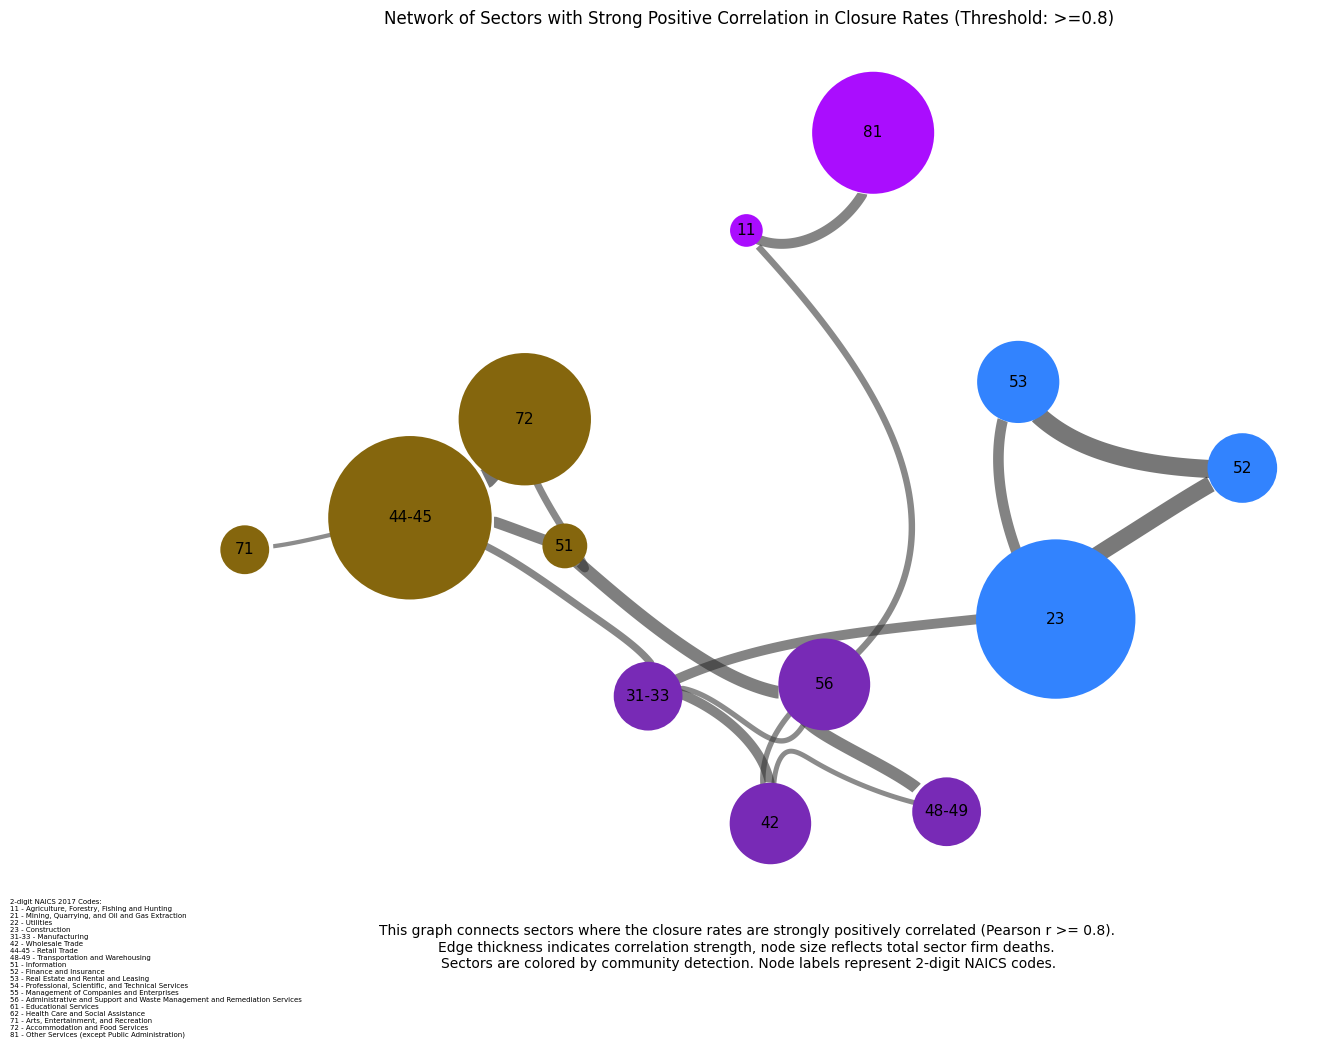

In [13]:
import community.community_louvain as co
import networkx as nx
from collections import defaultdict
import matplotlib.pyplot as plt
from netgraph import Graph # Importing Graph from netgraph
import plotly.express as px

print("\nNetwork Graph of Sector Co-occurrence based on Closure Rate Correlation")

# Define a correlation threshold for creating edges (same as for states)
correlation_threshold = 0.8

# Create edges based on the sector correlation matrix
correlation_edges_sectors = []
for i in range(len(corr_matrix_sectors.index)):
    for j in range(i + 1, len(corr_matrix_sectors.columns)):
        sector1 = corr_matrix_sectors.index[i]
        sector2 = corr_matrix_sectors.columns[j]
        correlation_value = corr_matrix_sectors.iloc[i, j]
        if correlation_value >= correlation_threshold: # Only consider strong positive correlations
            correlation_edges_sectors.append({'u': sector1, 'v': sector2, 'weight': correlation_value})

# Calculating node sizes, indicating total firm deaths per sector
sector_total_closures = df.groupby('sector_name')['firmdeath_firms'].sum()

# Creating the NetworkX graph
G_sectors = nx.Graph()
for edge in correlation_edges_sectors:
    G_sectors.add_edge(edge['u'], edge['v'], weight=edge['weight'])

# Filtering out sectors that are not connected in the graph (isolates)
isolates_sectors = list(nx.isolates(G_sectors))
G_sectors.remove_nodes_from(isolates_sectors)

# Performing community detection
partition_sectors = co.best_partition(G_sectors)
unique_communities_sectors = sorted(list(set(partition_sectors.values())))

# Mapping nodes to communities for netgraph's community layout
node_to_community_sectors = partition_sectors

# Generating colors for communities
community_colors_palette_sectors = px.colors.qualitative.Alphabet
community_color_map_sectors = {
    community_id: community_colors_palette_sectors[i % len(community_colors_palette_sectors)]
    for i, community_id in enumerate(unique_communities_sectors)
}

# Mapping each node to a color based on its community
node_color_sectors = {node: community_color_map_sectors[partition_sectors[node]] for node in G_sectors.nodes()}

# Scaling node sizes for netgraph
if not sector_total_closures.empty and len(G_sectors.nodes()) > 0: # Check if there are nodes after filtering isolates
    # Filter sector_total_closures to only include sectors present in the graph
    filtered_sector_total_closures = sector_total_closures[sector_total_closures.index.isin(G_sectors.nodes())]

    min_closures_sectors = filtered_sector_total_closures.min()
    max_closures_sectors = filtered_sector_total_closures.max()

    if max_closures_sectors == min_closures_sectors:
        node_size_by_sectors = {sector: 5 for sector in G_sectors.nodes()}
    else:
        node_size_by_sectors = {sector: 2 + 8 * (closures - min_closures_sectors) / (max_closures_sectors - min_closures_sectors)
                                for sector, closures in filtered_sector_total_closures.items()}
else:
    node_size_by_sectors = {} # Empty if no nodes or no closure data

# Creating edge widths based on correlation strength for netgraph
edge_widths_sectors = {}
for u, v, data in G_sectors.edges(data=True):
    # Scale correlation values (0.7 to 1.0) to a reasonable width range (e.g., 0.5 to 3.0)
    correlation_value = data['weight']
    scaled_width = 0.5 + (correlation_value - correlation_threshold) * (2.5 / (1.0 - correlation_threshold))
    edge_widths_sectors[(u,v)] = scaled_width

# Defining NAICS 2017 Codes and their corresponding sector names for direct labels
naics_mapping = {
    '11': 'Agriculture, Forestry, Fishing and Hunting',
    '21': 'Mining, Quarrying, and Oil and Gas Extraction',
    '22': 'Utilities',
    '23': 'Construction',
    '31-33': 'Manufacturing',
    '42': 'Wholesale Trade',
    '44-45': 'Retail Trade',
    '48-49': 'Transportation and Warehousing',
    '51': 'Information',
    '52': 'Finance and Insurance',
    '53': 'Real Estate and Rental and Leasing',
    '54': 'Professional, Scientific, and Technical Services',
    '55': 'Management of Companies and Enterprises',
    '56': 'Administrative and Support and Waste Management and Remediation Services',
    '61': 'Educational Services',
    '62': 'Health Care and Social Assistance',
    '71': 'Arts, Entertainment, and Recreation',
    '72': 'Accommodation and Food Services',
    '81': 'Other Services (except Public Administration)'
}

# Creating a reverse mapping for node labels, converting full sector names to NAICS codes
sector_to_naics = {v: k for k, v in naics_mapping.items()}

# Preparing node labels using NAICS codes
node_labels_sectors = {node: sector_to_naics.get(node, node) for node in G_sectors.nodes()}

fig_sectors, ax_sectors = plt.subplots(figsize=(15, 12)) # Adjusting figure size as needed

Graph(G_sectors,
      node_color=node_color_sectors, # Indicating the community each belongs to
      node_edge_width=0,     # Removing black border around nodes
      edge_width=edge_widths_sectors,        # Using calculated edge widths
      edge_alpha=0.6,        # Setting alpha
      node_layout='community', node_layout_kwargs=dict(node_to_community=node_to_community_sectors),
      node_size=node_size_by_sectors, # Using the calculated node sizes
      node_labels=node_labels_sectors,
      edge_layout='bundled',
      ax=ax_sectors,
)

ax_sectors.set_facecolor('white') # Setting the background to white

# Adding the title and explanation (static for netgraph)
ax_sectors.set_title(f'Network of Sectors with Strong Positive Correlation in Closure Rates (Threshold: >={correlation_threshold})')
plt.text(0.5, -0.05,
         f"This graph connects sectors where the closure rates are strongly positively correlated (Pearson r >= {correlation_threshold}). \nEdge thickness indicates correlation strength, node size reflects total sector firm deaths. \nSectors are colored by community detection. Node labels represent 2-digit NAICS codes.",
         horizontalalignment='center',
         verticalalignment='center',
         transform=ax_sectors.transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Formatting the legend text
legend_text = "2-digit NAICS 2017 Codes:\n" + "\n".join([f"{code} - {name}" for code, name in naics_mapping.items()])

# Adding the legend with a smaller font size below the main explanation
plt.figtext(0.02, 0.02, legend_text, fontsize=5, ha='left', va='bottom', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.show()

### **Sector-Pair-Year Aggregation and Co-occurrence Target Definition**

This section prepares the data for the TCN model by transforming the sector-year level data into a sector-pair-year format. This involves creating unique pairs of sectors for each year and generating new features based on the differences between these paired sectors. A binary co-occurrence target is also defined based on the correlation of closure rates between sectors.

**Steps:**

*   **Sector-Year Base Aggregation:** The `df` is first aggregated to a `sector_name`-`year` level (`sector_level_df_base`). For each sector and year, `firmdeath_firms` are summed, and other `base_features` (closure rates, economic indicators, lagged features, moving averages, YoY growth rates, and sector embeddings) are averaged. This provides a baseline set of features for each sector in each year.
*   **Generate Unique Sector Pairs:** All unique combinations of sector pairs (e.g., Agriculture-Mining, Agriculture-Utilities, but not Mining-Agriculture or Agriculture-Agriculture) are generated from the `sector_level_df_base`.
*   **Create Initial Sector-Pair DataFrame:** An initial DataFrame (`sector_pair_df`) is constructed containing all possible `year`-`sector_name_1`-`sector_name_2` combinations.
*   **Merge Features for Sector 1 and Sector 2:** The `sector_level_df_base` is merged twice with `sector_pair_df`: once to add features for `sector_name_1` (suffixed with `_1`) and once for `sector_name_2` (suffixed with `_2`). This brings all relevant features for both sectors in a pair into a single row for each year.
*   **Calculate Difference Features:** For a defined set of `features_to_difference` (excluding `firmdeath_firms`), new features are created representing the absolute difference between the values for `sector_name_1` and `sector_name_2` (e.g., `closure_rate_diff = closure_rate_1 - closure_rate_2`).
*   **Define Co-occurrence Target:** A binary target variable, `cooccurrence_target_pair_sectors`, is created. It is set to `1` if the Pearson correlation coefficient between `sector_name_1` and `sector_name_2` in the `corr_matrix_sectors` (from previous EDA) is greater than or equal to a `correlation_threshold_for_target` (currently 0.8); otherwise, it's `0`. This indicates whether a strong co-movement in closure rates exists between the sector pair.
*   **Final Cleaning and Renaming:** Any rows with missing values are dropped, and the resulting `sector_pair_df` is renamed to `sector_level_df` to be used in subsequent modeling steps.

In [22]:
import pandas as pd
import numpy as np
from itertools import combinations

print("Generating sector-pair-year data with difference features and co-occurrence target...")

# 1. Aggregate df to sector-year level (base features for each sector)
base_features_sectors = [
    'closure_rate',
    'closure_rate_firms',
    'job_destruction_rate',
    'net_job_creation_rate',
    'reallocation_rate',
    'income',
    'population',
    'employment_density',
    'emp',
    'lag1_closure_rate',
    'lag2_closure_rate',
    'ma3_closure_rate',
    'ma3_job_destruction_rate',
    'income_yoy',
    'population_yoy',
    'employment_yoy'
]

agg_funcs_sectors = {
    'firmdeath_firms': 'sum' # Keep firmdeath_firms for potential future use or context
}
for col in base_features_sectors:
    if col not in agg_funcs_sectors:
        agg_funcs_sectors[col] = 'mean'

sector_level_df_base = df.groupby(['sector_name', 'year']).agg(agg_funcs_sectors).reset_index()

# Merge sector embeddings into the base DataFrame
sector_level_df_base = sector_level_df_base.merge(embedding_df_sectors, left_on='sector_name', right_index=True, how='left')

sector_level_df_base = sector_level_df_base.dropna() # Drop NaNs that might arise from initial feature engineering or missing embeddings

print("Sector-level base aggregation complete. Shape:", sector_level_df_base.shape)

# 2. Generate unique sector pairs
unique_sectors = sector_level_df_base['sector_name'].unique()
sector_pairs_list = list(combinations(unique_sectors, 2)) # Get unique combinations (A,B) not (B,A) or (A,A)

# 3. Create initial DataFrame of sector pairs and years
all_years_sectors = sector_level_df_base['year'].unique()

sector_pair_data = []
for year in all_years_sectors:
    for s1, s2 in sector_pairs_list:
        sector_pair_data.append({'year': year, 'sector_name_1': s1, 'sector_name_2': s2})

sector_pair_df = pd.DataFrame(sector_pair_data)

# 4. Merge features for sector_1
sector_pair_df = sector_pair_df.merge(sector_level_df_base,
                                    left_on=['year', 'sector_name_1'],
                                    right_on=['year', 'sector_name'],
                                    how='inner',
                                    suffixes=('_1', ''))
sector_pair_df = sector_pair_df.drop(columns=['sector_name'])

# 5. Merge features for sector_2
sector_pair_df = sector_pair_df.merge(sector_level_df_base,
                                    left_on=['year', 'sector_name_2'],
                                    right_on=['year', 'sector_name'],
                                    how='inner',
                                    suffixes=('_1', '_2'))
sector_pair_df = sector_pair_df.drop(columns=['sector_name'])

# 6. Calculate difference features
# Features that are suitable for differencing
features_to_difference_sectors = [f for f in base_features_sectors if f not in ['firmdeath_firms']]

for feature in features_to_difference_sectors:
    sector_pair_df[f'{feature}_diff'] = sector_pair_df[f'{feature}_1'] - sector_pair_df[f'{feature}_2']

# 7. Define Co-occurrence Target based on overall corr_matrix_sectors and threshold
correlation_threshold_for_target_sectors = 0.8 # Consistent with network graph

sector_pair_df['cooccurrence_target_pair_sectors'] = sector_pair_df.apply(
    lambda row:
        1 if row['sector_name_1'] in corr_matrix_sectors.index and row['sector_name_2'] in corr_matrix_sectors.columns and \
             corr_matrix_sectors.loc[row['sector_name_1'], row['sector_name_2']] >= correlation_threshold_for_target_sectors
        else 0,
    axis=1
)

# 8. Final Cleaning
sector_pair_df = sector_pair_df.dropna()

# Renaming the final DataFrame for clarity
sector_level_df_tcn = sector_pair_df # Using a different name to avoid conflict with state_level_df

print("Sector-pair-year aggregated DataFrame (sector_level_df_tcn) generation complete. Head:")
display(sector_level_df_tcn.head())
print(f"Final sector_level_df_tcn shape: {sector_level_df_tcn.shape}")

Generating sector-pair-year data with difference features and co-occurrence target...
Sector-level base aggregation complete. Shape: (456, 27)
Sector-pair-year aggregated DataFrame (sector_level_df_tcn) generation complete. Head:


,year,sector_name_1,sector_name_2,firmdeath_firms_1,closure_rate_1,closure_rate_firms_1,job_destruction_rate_1,net_job_creation_rate_1,reallocation_rate_1,income_1,...,employment_density_diff,emp_diff,lag1_closure_rate_diff,lag2_closure_rate_diff,ma3_closure_rate_diff,ma3_job_destruction_rate_diff,income_yoy_diff,population_yoy_diff,employment_yoy_diff,cooccurrence_target_pair_sectors
0,2000-01-01,Accommodation and Food Services,Administrative and Support and Waste Managemen...,23829.166667,0.075887,0.09145,15.562608,-0.928163,24.904917,71424.4,...,0.975127,1343.542222,-0.012460,-0.010811,-0.011074,-3.303732,0.0,0.0,-4.121118,0
1,2000-01-01,Accommodation and Food Services,"Agriculture, Forestry, Fishing and Hunting",23829.166667,0.075887,0.09145,15.562608,-0.928163,24.904917,71424.4,...,3.738717,19277.650230,0.001381,-0.004186,-0.001293,-3.776452,0.0,0.0,-0.845718,0
2,2000-01-01,Accommodation and Food Services,"Arts, Entertainment, and Recreation",23829.166667,0.075887,0.09145,15.562608,-0.928163,24.904917,71424.4,...,3.187027,16165.864444,0.006716,0.004059,0.005224,-0.475769,0.0,0.0,-4.452909,0
3,2000-01-01,Accommodation and Food Services,Construction,23829.166667,0.075887,0.09145,15.562608,-0.928163,24.904917,71424.4,...,1.430703,6615.548889,0.004698,0.011864,0.005367,-2.910070,0.0,0.0,-0.072670,0
4,2000-01-01,Accommodation and Food Services,Educational Services,23829.166667,0.075887,0.09145,15.562608,-0.928163,24.904917,71424.4,...,2.880401,14241.228889,0.018642,0.017527,0.018162,3.674774,0.0,0.0,-9.433620,0


Final sector_level_df_tcn shape: (4104, 70)


### **TCN Model Implementation: Data Preparation (Sector-Level)**

Preparing `sector_level_df_tcn` by transforming it into sequential data. Each sequence will represent a time series of features for a given sector pair, leading up to a target `cooccurrence_target_pair_sectors`.

In [23]:
from sklearn.preprocessing import StandardScaler

# Feature and Target Selection for Sector TCN

# Identifying all difference features and sector embeddings differences
X_cols_sectors = [col for col in sector_level_df_tcn.columns if col.endswith('_diff')]
y_col_sectors = 'cooccurrence_target_pair_sectors'

# Drop rows where any of the selected columns might be NaN
current_df_sectors = sector_level_df_tcn[X_cols_sectors + [y_col_sectors] + ['year', 'sector_name_1', 'sector_name_2']].dropna().copy()

# Scale numerical features
scaler_sectors = StandardScaler()
current_df_sectors[X_cols_sectors] = scaler_sectors.fit_transform(current_df_sectors[X_cols_sectors])

print(f"Selected {len(X_cols_sectors)} features for X (sectors).")
print(f"Data shape after feature selection and scaling (sectors): {current_df_sectors.shape}")
print(current_df_sectors[X_cols_sectors].head())

# Creating Sequences for TCN (Sectors)
sequence_length_sectors = 3 # Consistent with state model

X_sequences_sectors = []
y_sequences_sectors = []
sector_pair_indices_tcn = []

# Grouping by sector pairs and generate sequences
for (s1, s2), group in current_df_sectors.groupby(['sector_name_1', 'sector_name_2']):
    # Sorting by year to ensure correct sequence order
    group = group.sort_values('year').reset_index(drop=True)

    if len(group) >= sequence_length_sectors:
        for i in range(len(group) - sequence_length_sectors + 1):
            # Features for the sequence_length_sectors years
            X_sequences_sectors.append(group.iloc[i : i + sequence_length_sectors][X_cols_sectors].values)
            # Target for the *last* year in the sequence
            y_sequences_sectors.append(group.iloc[i + sequence_length_sectors - 1][y_col_sectors])
            sector_pair_indices_tcn.append((s1, s2, group.iloc[i + sequence_length_sectors - 1]['year']))

X_sequences_sectors = np.array(X_sequences_sectors)
y_sequences_sectors = np.array(y_sequences_sectors)

print(f"Generated {len(X_sequences_sectors)} sequences (sectors).")
print(f"X_sequences_sectors shape: {X_sequences_sectors.shape}")
print(f"y_sequences_sectors shape: {y_sequences_sectors.shape}")

# Check for target distribution before splitting
print("Target distribution in full dataset (sectors):")
print(pd.Series(y_sequences_sectors).value_counts(normalize=True))

Selected 16 features for X (sectors).
Data shape after feature selection and scaling (sectors): (4104, 20)
   closure_rate_diff  closure_rate_firms_diff  job_destruction_rate_diff  \
0          -0.535937                -0.252399                  -1.100441   
1          -0.268689                 0.160460                  -1.000238   
2          -0.088905                 0.260425                  -0.383561   
3          -0.250256                 0.179503                  -0.786192   
4           0.315160                 0.673210                   0.547449   

   net_job_creation_rate_diff  reallocation_rate_diff  income_diff  \
0                   -0.431457               -0.834649    -0.106673   
1                    0.767500                0.433537     0.505281   
2                    0.096074                0.320980    -0.106673   
3                   -0.132057               -1.118339    -0.106673   
4                   -0.523466                0.937256    -0.106673   

   population_d

### **TCN Model Implementation: Data Splitting (Train, Validation, Test) (Sector-Level)**

Splitting the sector-level data for time-series models while ensuring no data leakage between sector pairs. Stratified splitting maintains the proportions of co-occurrence targets.

In [24]:
from sklearn.model_selection import train_test_split

# Getting unique sector pairs and their corresponding average target for stratification
unique_sector_pairs = current_df_sectors[['sector_name_1', 'sector_name_2']].drop_duplicates().values

# Creating a DataFrame for unique sector pairs with an aggregated target for stratification
sector_pair_target_means = sector_level_df_tcn.groupby(['sector_name_1', 'sector_name_2'])[y_col_sectors].mean().reset_index()
sector_pair_target_means['stratify_target'] = (sector_pair_target_means[y_col_sectors] > 0).astype(int) # Binary for stratification

# Performing stratified train-test split on unique sector pairs
s_train_pairs_sectors, s_test_pairs_sectors, _, _ = train_test_split(
    unique_sector_pairs, sector_pair_target_means['stratify_target'], test_size=0.2, random_state=42, stratify=sector_pair_target_means['stratify_target']
)

# Further split training pairs into train and validation pairs
s_train_pairs_sectors, s_val_pairs_sectors, _, _ = train_test_split(
    s_train_pairs_sectors, sector_pair_target_means.loc[sector_pair_target_means[['sector_name_1', 'sector_name_2']].apply(tuple, 1).isin(map(tuple, s_train_pairs_sectors)), 'stratify_target'],
    test_size=0.25, random_state=42, stratify=sector_pair_target_means.loc[sector_pair_target_means[['sector_name_1', 'sector_name_2']].apply(tuple, 1).isin(map(tuple, s_train_pairs_sectors)), 'stratify_target']
)

# Function to extract sequences for given sector pairs
def get_sequences_for_sector_pairs(pairs_list):
    X = []
    y = []
    for s1, s2 in pairs_list:
        for i, (sp1, sp2, year) in enumerate(sector_pair_indices_tcn):
            if (s1, s2) == (sp1, sp2):
                X.append(X_sequences_sectors[i])
                y.append(y_sequences_sectors[i])
    return np.array(X), np.array(y)

X_train_sectors, y_train_sectors = get_sequences_for_sector_pairs(s_train_pairs_sectors)
X_val_sectors, y_val_sectors = get_sequences_for_sector_pairs(s_val_pairs_sectors)
X_test_sectors, y_test_sectors = get_sequences_for_sector_pairs(s_test_pairs_sectors)

print(f"Training sequences (sectors): X_train_sectors.shape={X_train_sectors.shape}, y_train_sectors.shape={y_train_sectors.shape}")
print(f"Validation sequences (sectors): X_val_sectors.shape={X_val_sectors.shape}, y_val_sectors.shape={y_val_sectors.shape}")
print(f"Test sequences (sectors): X_test_sectors.shape={X_test_sectors.shape}, y_test_sectors.shape={y_test_sectors.shape}")

print("\nTarget distribution in Training set (sectors):")
print(pd.Series(y_train_sectors).value_counts(normalize=True))
print("\nTarget distribution in Validation set (sectors):")
print(pd.Series(y_val_sectors).value_counts(normalize=True))
print("\nTarget distribution in Test set (sectors):")
print(pd.Series(y_test_sectors).value_counts(normalize=True))

Training sequences (sectors): X_train_sectors.shape=(2244, 3, 16), y_train_sectors.shape=(2244,)
Validation sequences (sectors): X_val_sectors.shape=(748, 3, 16), y_val_sectors.shape=(748,)
Test sequences (sectors): X_test_sectors.shape=(770, 3, 16), y_test_sectors.shape=(770,)

Target distribution in Training set (sectors):
0    0.872549
1    0.127451
Name: proportion, dtype: float64

Target distribution in Validation set (sectors):
0    0.970588
1    0.029412
Name: proportion, dtype: float64

Target distribution in Test set (sectors):
0    0.914286
1    0.085714
Name: proportion, dtype: float64


### **TCN Model Implementation: TCN Architecture (Sector-Level)**

Reusing the previously defined TCN architecture for sector-level co-occurrence prediction.

In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the TCN model (reusing the same architecture)

# Define the TCN model function
def build_tcn_model(input_shape, num_classes=1):
    inputs = keras.Input(shape=input_shape)
    x = inputs

    # TCN block with dilated convolutions and residual connections
    num_filters = 64
    kernel_size = 2
    dropout_rate = 0.2

    for i in range(3): # Three TCN blocks
        dilation_rate = 2**i

        # Residual block
        res_x = x

        # First convolutional layer
        x = layers.Conv1D(
            filters=num_filters,
            kernel_size=kernel_size,
            dilation_rate=dilation_rate,
            padding='causal',
            activation='relu',
            kernel_initializer='he_normal'
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout_rate)(x)

        # Second convolutional layer
        x = layers.Conv1D(
            filters=num_filters,
            kernel_size=kernel_size,
            dilation_rate=dilation_rate,
            padding='causal',
            activation='relu',
            kernel_initializer='he_normal'
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout_rate)(x)

        # 1x1 convolution for residual connection if dimensions don't match
        if res_x.shape[-1] != num_filters:
            res_x = layers.Conv1D(filters=num_filters, kernel_size=1, padding='same')(res_x)

        x = layers.Add()([res_x, x])
        x = layers.Activation('relu')(x)

    x = layers.GlobalAveragePooling1D()(x) # Aggregate sequence output
    outputs = layers.Dense(num_classes, activation='sigmoid')(x) # Binary classification

    model = keras.Model(inputs, outputs)
    return model

input_shape_sectors = X_train_sectors.shape[1:]  # (sequence_length, num_features)
num_features_sectors = input_shape_sectors[1]

# Re-instantiate the model for sectors to ensure fresh weights
tcn_model_sectors = build_tcn_model(input_shape_sectors)

tcn_model_sectors.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 3, 16)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 3, 64)     │      2,112 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 64)     │        256 │ conv1d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 3, 64)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 3, 64)     │      8,256 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 64)     │        256 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 3, 64)     │      1,088 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 3, 64)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 3, 64)     │          0 │ conv1d_9[0][0],   │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 3, 64)     │          0 │ add_3[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 3, 64)     │      8,256 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 64)     │        256 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 3, 64)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 3, 64)     │      8,256 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 64)     │        256 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 3, 64)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 3, 64)     │          0 │ activation_3[0][… │
│                     │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 3, 64)     │          0 │ add_4[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 3, 64)     │      8,256 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 64)     │        256 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 46,081 (180.00 KB)

 Trainable params: 45,313 (177.00 KB)

 Non-trainable params: 768 (3.00 KB)

### **TCN Model Implementation: Model Evaluation (Sector-Level)**

Evaluating the TCN model's performance on the unseen test set for sector co-occurrence.

Total (sectors): 2244, Positive (sectors): 286, Negative (sectors): 1958
Class weights (sectors): {0: np.float64(0.5730337078651686), 1: np.float64(3.923076923076923)}
Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.5428 - auc: 0.7615 - loss: 0.5935 - val_accuracy: 0.8944 - val_auc: 0.4578 - val_loss: 0.3451
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7389 - auc: 0.8514 - loss: 0.4721 - val_accuracy: 0.7139 - val_auc: 0.4743 - val_loss: 0.4316
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7522 - auc: 0.8786 - loss: 0.4278 - val_accuracy: 0.6952 - val_auc: 0.4848 - val_loss: 0.4484
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7830 - auc: 0.8955 - loss: 0.4007 - val_accuracy: 0.6885 - val_auc: 0.5310 - val_loss: 0.4940
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7790 - auc: 0.8960 - loss: 0.3888 - val_accuracy: 0.6912 - val_auc: 0.5092 - val_loss: 0.5030
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━

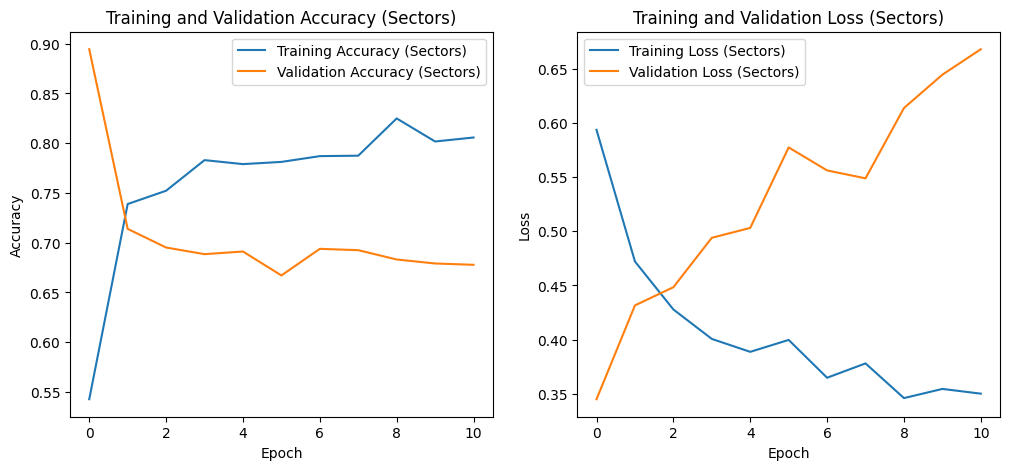

Test Loss (Sectors): 0.3760
Test Accuracy (Sectors): 0.8688
Test AUC (Sectors): 0.6130
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

Classification Report (Sectors):
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       704
           1       0.03      0.02      0.02        66

    accuracy                           0.87       770
   macro avg       0.47      0.48      0.47       770
weighted avg       0.84      0.87      0.85       770



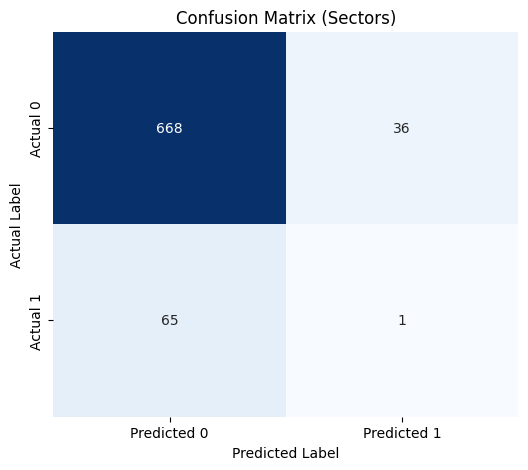

In [26]:
# Compile and Train Sector TCN Model

# Handling class imbalance by calculating class weights
neg_sectors, pos_sectors = np.bincount(y_train_sectors.astype(int))
total_sectors = neg_sectors + pos_sectors

print(f'Total (sectors): {total_sectors}, Positive (sectors): {pos_sectors}, Negative (sectors): {neg_sectors}')

# Scaling by total to make the sum of weights equal to 1
weight_for_0_sectors = (1 / neg_sectors) * (total_sectors / 2.0)
weight_for_1_sectors = (1 / pos_sectors) * (total_sectors / 2.0)

class_weight_sectors = {0: weight_for_0_sectors, 1: weight_for_1_sectors}
print(f'Class weights (sectors): {class_weight_sectors}')

# Compile the model
tcn_model_sectors.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.BinaryAccuracy(name='accuracy'),
        keras.metrics.AUC(name='auc')
    ]
)

# Define callbacks
early_stopping_sectors = EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, mode='min'
)

# Train the model
history_sectors = tcn_model_sectors.fit(
    X_train_sectors, y_train_sectors,
    epochs=50, # Adjust epochs as needed
    batch_size=32,
    validation_data=(X_val_sectors, y_val_sectors),
    callbacks=[early_stopping_sectors],
    class_weight=class_weight_sectors
)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_sectors.history['accuracy'], label='Training Accuracy (Sectors)')
plt.plot(history_sectors.history['val_accuracy'], label='Validation Accuracy (Sectors)')
plt.title('Training and Validation Accuracy (Sectors)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_sectors.history['loss'], label='Training Loss (Sectors)')
plt.plot(history_sectors.history['val_loss'], label='Validation Loss (Sectors)')
plt.title('Training and Validation Loss (Sectors)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluate the model on the test set
loss_sectors, accuracy_sectors, auc_sectors = tcn_model_sectors.evaluate(X_test_sectors, y_test_sectors, verbose=0)
print(f"Test Loss (Sectors): {loss_sectors:.4f}")
print(f"Test Accuracy (Sectors): {accuracy_sectors:.4f}")
print(f"Test AUC (Sectors): {auc_sectors:.4f}")

# Make predictions
y_pred_proba_sectors = tcn_model_sectors.predict(X_test_sectors)
y_pred_sectors = (y_pred_proba_sectors > 0.5).astype(int)

# Classification Report
print("\nClassification Report (Sectors):")
print(classification_report(y_test_sectors, y_pred_sectors))

# Confusion Matrix
cm_sectors = confusion_matrix(y_test_sectors, y_pred_sectors)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_sectors, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix (Sectors)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### **TCN Model Implementation: Feature Importance (Sector-Level)**

Calculating permutation feature importance for the sector-level TCN model to understand which features most impact its predictive performance.

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Calculating permutation feature importance (sectors)...
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
  - Feature 'closure_rate_diff': Importance = 0.0147
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  - Feature 'closure_rate_firms_diff': Importance = 0.0134
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  - Feature 'job_destruction_rate_diff': Importance = 0.0427
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  - Feature 'net_job_creation_rate_diff': Importance = 0.0239
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  - Feature 'reallocation_rate_diff': Importance = 0.0072
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  - Feature 'income_diff': Importance = 0.0268
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  - Feature 'population_diff': Importance = 0.0185
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
  - Feature 'employment_density_diff': Importance = 0.0523
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  - Feature 'emp_diff': Importance = 0.1019
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  - Feature 'lag1_clo

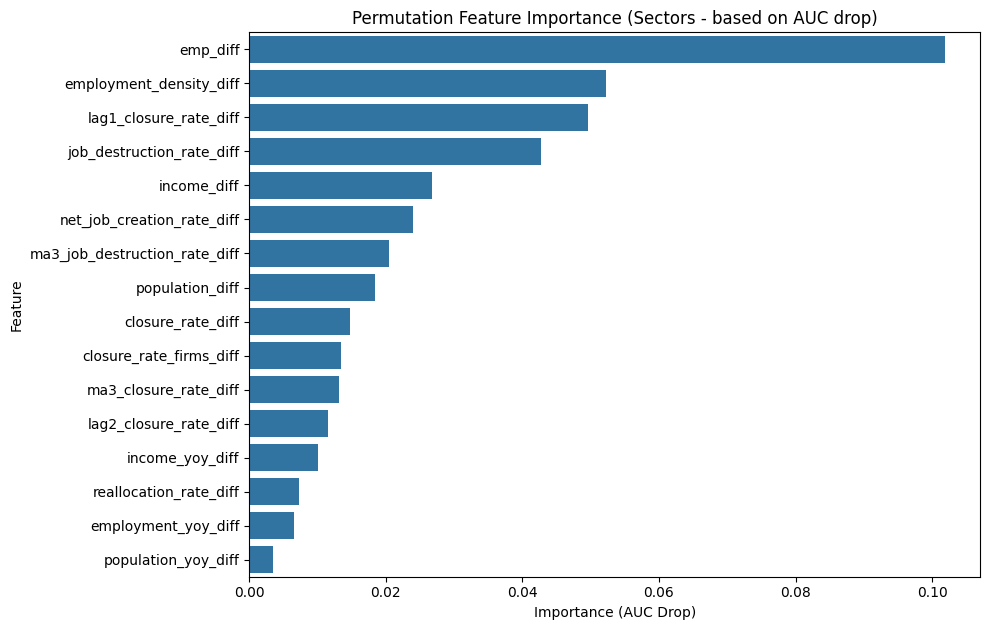

,Feature,Importance
0,emp_diff,0.101928
1,employment_density_diff,0.052256
2,lag1_closure_rate_diff,0.049608
3,job_destruction_rate_diff,0.042678
4,income_diff,0.026795
5,net_job_creation_rate_diff,0.023933
6,ma3_job_destruction_rate_diff,0.020489
7,population_diff,0.018466
8,closure_rate_diff,0.014678
9,closure_rate_firms_diff,0.013408


In [27]:
# Calculate Permutation Feature Importance (Sectors)

# Baseline performance
original_auc_sectors = roc_auc_score(y_test_sectors, tcn_model_sectors.predict(X_test_sectors))

feature_importances_sectors = {}

print("Calculating permutation feature importance (sectors)...")
for i, feature_name in enumerate(X_cols_sectors):
    # Create a copy of the test data
    X_test_permuted_sectors = X_test_sectors.copy()

    # Permute the values of the current feature across all time steps in the sequences
    X_test_permuted_sectors[:, :, i] = np.random.permutation(X_test_permuted_sectors[:, :, i]) # Shuffles within each timestep/sequence

    # Predict with permuted data
    permuted_auc_sectors = roc_auc_score(y_test_sectors, tcn_model_sectors.predict(X_test_permuted_sectors))

    # Calculate importance as the drop in AUC
    importance_sectors = abs(original_auc_sectors - permuted_auc_sectors)
    feature_importances_sectors[feature_name] = importance_sectors
    print(f"  - Feature '{feature_name}': Importance = {importance_sectors:.4f}")

# Sort and visualize feature importances
sorted_importance_sectors = sorted(feature_importances_sectors.items(), key=lambda item: item[1], reverse=True)

importance_df_sectors = pd.DataFrame(sorted_importance_sectors, columns=['Feature', 'Importance'])

plt.figure(figsize=(10, len(X_cols_sectors) * 0.4))
sns.barplot(x='Importance', y='Feature', data=importance_df_sectors)
plt.title('Permutation Feature Importance (Sectors - based on AUC drop)')
plt.xlabel('Importance (AUC Drop)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

display(importance_df_sectors)